In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


# Summary

At this notebook:
- Handles multiple dataset creations, relabel some labels.
- Show how dense features of Dinov3 can be perceived over different input dimensions (512,1024,2048).
- Evaluate the impact of tilling the full-images into tiles of 512,1024 or 2048. 
- Compute full embeddings and patch embedding of three datasets( NC, WP and UM test)
- Compute the visualization of the datasets and generate nice plots for the thesis. 
- Tile the dataset into a given tile size 1024 with 224 overlap and create subdataset instances.


In [2]:
fo.list_datasets(
    
)

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [3]:
dataset = fo.load_dataset("tiles_merged")

In [5]:
session = fo.launch_app(dataset,auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [6]:
dataset.first()

<Sample: {
    'id': '6a33c2d08be790ca1e89a2ac',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH014205-611f8c7997ea4_1808__tile_0_800_t1024_o224.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 90472,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 18, 11, 29, 1, 457000),
    'last_modified_at': datetime.datetime(2026, 6, 30, 11, 52, 21, 103000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33c2c48be790ca1e898130',
                'attributes': {},
                'tags': [],
                'label': '1',
                'bounding_box': [0.4365234375, 0.0556640625, 0.04296875, 0.046875],
                'mask': None,
                'mask_path': None,
                'confidence': None,
      

In [5]:
dataset.list_brain_runs()

['tsnev1', 'umap']

In [6]:
dataset.delete_brain_run('obj_emb_tiles')

In [7]:
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [15]:
dataset.count_values('ground_truth.detections.label')

{'dugong': 3546}

In [14]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [12]:
dataset.count_values('ground_truthv2.detections.label')

{'calf': 79, 'dugong': 183}

### Rename the label Dugong to dugong

In [11]:
for sample in dataset.iter_samples(autosave=True, progress=True):
    if not sample.ground_truthv2 or not sample.ground_truthv2.detections:
        continue
    for det in sample.ground_truthv2.detections:
        det.label = det.label.lower()
    
    sample.save()

 100% |█████████████████| 152/152 [7.9s elapsed, 0s remaining, 18.4 samples/s]      


In [40]:

session = fo.launch_app(dataset,
                        auto=False,
                        port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [16]:
session.refresh()

In [12]:
session.selected

['6a303cf33e03af1d71b350a9',
 '6a303cf33e03af1d71b350b5',
 '6a303cf33e03af1d71b350c4',
 '6a303cf33e03af1d71b350ef']

In [14]:
dataset

Name:        WP_125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [16]:
dataset.count_values("mission_name")

{'GAM': 27, 'FRIWEN': 63, 'MANTASANDY': 3, 'UM': 59}

In [17]:
dataset.values("filepath")

['/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_4.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_5.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_18.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_138.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_123.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_72.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_133.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M1/images/MAN_P4_GAM_M1_F2_GSP_DJI

# Analysing cosine similarity with a Dinov3

In [29]:
from dotenv import load_dotenv
load_dotenv()

import fiftyone.utils.torch as fout
from huggingface_hub import login

if "HUGGING_FACE_API" in os.environ:
    login(token=os.environ["HUGGING_FACE_API"])

In [30]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)



Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [31]:

from transformers import AutoImageProcessor, AutoModel
import fiftyone.utils.transformers as fout

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"


processor = AutoImageProcessor.from_pretrained(MODEL_ID)

print("=== Processor defaults ===")
print(f"  do_resize        : {processor.do_resize}")
print(f"  size             : {processor.size}")
print(f"  default_to_square: {processor.default_to_square}")
print(f"  do_rescale       : {processor.do_rescale}")
print(f"  do_normalize     : {processor.do_normalize}")
print(f"  image_mean       : {processor.image_mean}")
print(f"  image_std        : {processor.image_std}")

# ── Disable resize so OUR crop reaches the model untouched ───────────────────
# We keep rescale (0→1 float) and normalize (ImageNet stats) since those
# are independent of spatial dimensions and DINOv2 always expects them.
processor.do_resize = False
processor.default_to_square = False   # defensive — has no effect if do_resize=False

print("\n=== Processor after patch ===")
print(f"  do_resize        : {processor.do_resize}")
print(f"  default_to_square: {processor.default_to_square}")
print(f"  do_rescale       : {processor.do_rescale}   ← kept ON")
print(f"  do_normalize     : {processor.do_normalize}  ← kept ON")

# ── Sanity check: what does the processor produce for a known input size? ────
from PIL import Image
import numpy as np

STRIDE      = 16
TEST_SIZE   = 512    # one of our intended crop sizes

dummy = Image.fromarray(np.zeros((TEST_SIZE, TEST_SIZE, 3), dtype=np.uint8))
out   = processor(images=dummy, return_tensors="pt")
tensor_shape = out["pixel_values"].shape   # (1, 3, H, W)

print(f"\n=== Sanity check (dummy {TEST_SIZE}×{TEST_SIZE} input) ===")
print(f"  pixel_values shape : {tuple(tensor_shape)}")
print(f"  Expected           : (1, 3, {TEST_SIZE}, {TEST_SIZE})")

expected_tokens = (TEST_SIZE // STRIDE) ** 2
print(f"  Expected patch tokens (stride {STRIDE}): {expected_tokens}  "
      f"({TEST_SIZE//STRIDE}×{TEST_SIZE//STRIDE} grid)")

assert tensor_shape[-2] == TEST_SIZE and tensor_shape[-1] == TEST_SIZE, (
    f"Processor is still resizing! Got {tuple(tensor_shape)}, "
    f"expected (1, 3, {TEST_SIZE}, {TEST_SIZE}). Check do_resize."
)
print("\n  Processor is correctly passing the image through at native resolution.")

# ── Load model ────────────────────────────────────────────────────────────────
base_model = AutoModel.from_pretrained(MODEL_ID)
model      = fout.convert_transformers_model(base_model, image_processor=processor)

print(f"\nModel loaded: {MODEL_ID}")
print(f"  fout model type: {type(model)}")

=== Processor defaults ===
  do_resize        : True
  size             : {'height': 224, 'width': 224}
  default_to_square: True
  do_rescale       : True
  do_normalize     : True
  image_mean       : [0.485, 0.456, 0.406]
  image_std        : [0.229, 0.224, 0.225]

=== Processor after patch ===
  do_resize        : False
  default_to_square: False
  do_rescale       : True   ← kept ON
  do_normalize     : True  ← kept ON

=== Sanity check (dummy 512×512 input) ===
  pixel_values shape : (1, 3, 512, 512)
  Expected           : (1, 3, 512, 512)
  Expected patch tokens (stride 16): 1024  (32×32 grid)

  Processor is correctly passing the image through at native resolution.


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]


Model loaded: facebook/dinov3-vitl16-pretrain-lvd1689m
  fout model type: <class 'fiftyone.utils.transformers.FiftyOneTransformer'>


In [32]:
# ── Cell 2 (revised): Model Audit — use base_model directly on correct device ─
import torch
import numpy as np
from PIL import Image

STRIDE    = 16
TEST_SIZE = 512
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

# ── Drop the fout wrapper — use base_model directly ──────────────────────────
# FiftyOneTransformer is designed for FiftyOne's .predict()/.embed() pipeline,
# not for raw tensor inference. base_model gives us full control over outputs.
base_model.to(DEVICE)
base_model.eval()
print(f"base_model on device: {next(base_model.parameters()).device}")

# ── Probe: raw pixel_values tensor, correct device ───────────────────────────
print(f"\n=== Probe: base_model + processor, input {TEST_SIZE}×{TEST_SIZE} ===")

dummy  = Image.fromarray(np.zeros((TEST_SIZE, TEST_SIZE, 3), dtype=np.uint8))
inputs = processor(images=dummy, return_tensors="pt")
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}   # ← move to GPU

print(f"  pixel_values dtype : {inputs['pixel_values'].dtype}")
print(f"  pixel_values device: {inputs['pixel_values'].device}")
print(f"  pixel_values shape : {tuple(inputs['pixel_values'].shape)}")

try:
    with torch.no_grad():
        out = base_model(**inputs, output_hidden_states=False)

    hidden      = out.last_hidden_state          # (1, 1 + n_reg + n_patches, dim)
    n_total     = hidden.shape[1]
    n_patches   = (TEST_SIZE // STRIDE) ** 2
    n_registers = n_total - 1 - n_patches        # auto-detect registers

    print(f"\n  last_hidden_state shape : {tuple(hidden.shape)}")
    print(f"  Total tokens            : {n_total}")
    print(f"  = 1 CLS + {n_registers} registers + {n_patches} patch tokens")
    print(f"  Embedding dim           : {hidden.shape[-1]}")
    print(f"  Patch token shape       : ({n_patches}, {hidden.shape[-1]})")
    print(f"\n  base_model works correctly: YES")

    # Store for downstream cells
    N_REGISTERS = n_registers
    EMBED_DIM   = hidden.shape[-1]

except Exception as e:
    print(f"  FAILED: {e}")
    raise

print(f"\n=== Constants locked for downstream cells ===")
print(f"  DEVICE      = {DEVICE}")
print(f"  STRIDE      = {STRIDE}")
print(f"  N_REGISTERS = {N_REGISTERS}")
print(f"  EMBED_DIM   = {EMBED_DIM}")

Device: cuda
base_model on device: cuda:0

=== Probe: base_model + processor, input 512×512 ===
  pixel_values dtype : torch.float32
  pixel_values device: cuda:0
  pixel_values shape : (1, 3, 512, 512)



  last_hidden_state shape : (1, 1029, 1024)
  Total tokens            : 1029
  = 1 CLS + 4 registers + 1024 patch tokens
  Embedding dim           : 1024
  Patch token shape       : (1024, 1024)

  base_model works correctly: YES

=== Constants locked for downstream cells ===
  DEVICE      = cuda
  STRIDE      = 16
  N_REGISTERS = 4
  EMBED_DIM   = 1024


# Functions for analysing dense feature map

In [33]:
#Data Loading & Crop Geometry 
import numpy as np
from PIL import Image
from pathlib import Path


# Group 1: Data Loading

def load_sample(dataset: fo.Dataset, identifier: str) -> fo.Sample:
    """
    Load a FiftyOne sample by sample_id or filepath.

    Parameters
    ----------
    dataset    : fo.Dataset
    identifier : sample_id string OR absolute filepath string

    Returns
    -------
    fo.Sample
    """
    # Try as sample_id first
    try:
        sample = dataset[identifier]
        print(f"Loaded by sample_id : {identifier}")
        return sample
    except KeyError:
        pass

    # Fall back to filepath
    view = dataset.match(fo.ViewField("filepath") == identifier)
    if len(view) == 0:
        raise ValueError(
            f"No sample found for identifier '{identifier}'. "
            "Provide a valid sample_id or filepath."
        )
    sample = view.first()
    print(f"Loaded by filepath  : {Path(identifier).name}")
    return sample


def get_centroid_pixels(sample: fo.Sample) -> tuple:
    """
    Extract the centroid of the largest ground_truth detection
    in absolute pixel coordinates.

    Parameters
    ----------
    sample : fo.Sample  — must have metadata and ground_truth populated

    Returns
    -------
    cx, cy      : float  — centroid in absolute pixels
    detection   : fo.Detection — the chosen detection (for bbox drawing later)
    img_w, img_h: int    — original image dimensions
    """
    if not sample.ground_truth or not sample.ground_truth.detections:
        raise ValueError(f"Sample {sample.id} has no ground_truth detections.")

    img_w = sample.metadata.width
    img_h = sample.metadata.height

    # Pick largest detection by bbox area
    det = max(
        sample.ground_truth.detections,
        key=lambda d: d.bounding_box[2] * d.bounding_box[3]
    )

    bx, by, bw, bh = det.bounding_box   # normalised [0,1] FiftyOne format
    cx = (bx + bw / 2) * img_w
    cy = (by + bh / 2) * img_h

    print(f"Image size          : {img_w} × {img_h} px")
    print(f"Largest detection   : label='{det.label}'  "
          f"bbox=[{bx:.4f}, {by:.4f}, {bw:.4f}, {bh:.4f}]")
    print(f"Centroid (absolute) : ({cx:.1f}, {cy:.1f}) px")

    return cx, cy, det, img_w, img_h


# ── Group 2: Crop Geometry ────────────────────────────────────────────────────

def compute_crop_window(
    cx: float, cy: float,
    crop_size: int,
    img_w: int, img_h: int,
) -> tuple:
    """
    Compute a crop_size × crop_size window centered on (cx, cy),
    sliding inward if the window overflows any image edge.
    Never pads — always stays within image boundaries.

    Parameters
    ----------
    cx, cy    : centroid in absolute pixels
    crop_size : desired square crop side length in pixels
    img_w     : image width  in pixels
    img_h     : image height in pixels

    Returns
    -------
    x0, y0, x1, y1 : int — top-left and bottom-right pixel coordinates
    shifted         : bool — True if the window was slid from centre
    """
    if crop_size > img_w or crop_size > img_h:
        raise ValueError(
            f"crop_size {crop_size} exceeds image dimensions {img_w}×{img_h}. "
            "Choose a smaller crop size for this image."
        )

    half = crop_size // 2

    # Start centered
    x0 = int(cx) - half
    y0 = int(cy) - half
    x1 = x0 + crop_size
    y1 = y0 + crop_size

    # Slide horizontally if needed
    if x0 < 0:
        x1 -= x0   # shift right
        x0  = 0
    elif x1 > img_w:
        x0 -= (x1 - img_w)   # shift left
        x1  = img_w

    # Slide vertically if needed
    if y0 < 0:
        y1 -= y0   # shift down
        y0  = 0
    elif y1 > img_h:
        y0 -= (y1 - img_h)   # shift up
        y1  = img_h

    shifted = not (abs(int(cx) - half - x0) < 1 and abs(int(cy) - half - y0) < 1)

    return x0, y0, x1, y1, shifted


def remap_centroid_to_crop(
    cx: float, cy: float,
    x0: int,   y0: int,
) -> tuple:
    """
    Recompute centroid coordinates relative to the crop's top-left corner.

    Parameters
    ----------
    cx, cy : centroid in original image absolute pixels
    x0, y0 : crop top-left in original image pixels

    Returns
    -------
    cx_crop, cy_crop : float — centroid within the crop coordinate space
    """
    return cx - x0, cy - y0


# ── Group 3: Token Space ──────────────────────────────────────────────────────

def get_token_grid_shape(crop_size: int, stride: int) -> tuple:
    """
    Returns (grid_h, grid_w) — the token grid dimensions for a square crop.

    Parameters
    ----------
    crop_size : side length of the square crop in pixels
    stride    : ViT patch stride (14 or 16)

    Returns
    -------
    grid_h, grid_w : int
    """
    grid = crop_size // stride
    return grid, grid


def pixels_to_token(
    px: float, py: float,
    stride: int,
    grid_h: int, grid_w: int,
) -> tuple:
    """
    Map a pixel position within a crop to its token grid index.
    Clamps to valid grid bounds.

    Parameters
    ----------
    px, py   : pixel position within the crop
    stride   : ViT patch stride
    grid_h   : token grid height
    grid_w   : token grid width

    Returns
    -------
    token_row, token_col : int
    """
    col = int(px / stride)
    row = int(py / stride)
    col = max(0, min(grid_w - 1, col))
    row = max(0, min(grid_h - 1, row))
    return row, col


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_geometry(crop_sizes: list[int], stride: int = STRIDE):
    print("=== Geometry smoke test ===\n")
    # Simulate a 4000×3000 image with centroid near the left edge
    img_w, img_h = 4000, 3000
    cx, cy = 300.0, 1500.0   # near left edge — forces a rightward slide

    print(f"Simulated image  : {img_w}×{img_h}  centroid=({cx},{cy})\n")

    for cs in crop_sizes:
        x0, y0, x1, y1, shifted = compute_crop_window(cx, cy, cs, img_w, img_h)
        cx_c, cy_c              = remap_centroid_to_crop(cx, cy, x0, y0)
        grid_h, grid_w          = get_token_grid_shape(cs, stride)
        tok_row, tok_col        = pixels_to_token(cx_c, cy_c, stride, grid_h, grid_w)

        print(f"  crop {cs:>4}px : window=({x0},{y0})→({x1},{y1})  "
              f"slid={'YES' if shifted else 'no '}  "
              f"centroid-in-crop=({cx_c:.1f},{cy_c:.1f})  "
              f"grid={grid_h}×{grid_w}  "
              f"anchor=({tok_row},{tok_col})")

    print("\n  All geometry functions OK.")

CROP_SIZES = [512, 1024, 2048]
_smoke_test_geometry(CROP_SIZES)

=== Geometry smoke test ===

Simulated image  : 4000×3000  centroid=(300.0,1500.0)

  crop  512px : window=(44,1244)→(556,1756)  slid=no   centroid-in-crop=(256.0,256.0)  grid=32×32  anchor=(16,16)
  crop 1024px : window=(0,988)→(1024,2012)  slid=YES  centroid-in-crop=(300.0,512.0)  grid=64×64  anchor=(32,18)
  crop 2048px : window=(0,476)→(2048,2524)  slid=YES  centroid-in-crop=(300.0,1024.0)  grid=128×128  anchor=(64,18)

  All geometry functions OK.


In [34]:
# ── Cell 4: Model Inference & Patch Token Extraction ─────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image


# ── Group 4: Model Inference ──────────────────────────────────────────────────

def load_pil_crop(sample: fo.Sample, x0: int, y0: int, x1: int, y1: int) -> Image.Image:
    """
    Open the sample image and return the specified crop as a PIL Image.
    Keeps the image in RGB regardless of source format.

    Parameters
    ----------
    sample      : fo.Sample — must have filepath populated
    x0, y0, x1, y1 : crop window in original image pixel coordinates

    Returns
    -------
    PIL.Image  (RGB, size = (x1-x0, y1-y0))
    """
    pil_img  = Image.open(sample.filepath).convert("RGB")
    pil_crop = pil_img.crop((x0, y0, x1, y1))

    actual_w, actual_h = pil_crop.size
    expected            = x1 - x0

    assert actual_w == expected and actual_h == expected, (
        f"Crop size mismatch: expected {expected}×{expected}, "
        f"got {actual_w}×{actual_h}. Check compute_crop_window output."
    )
    return pil_crop


def extract_patch_tokens(
    pil_crop  : Image.Image,
    processor,
    model     : torch.nn.Module,
    stride    : int,
    n_registers: int,
    device    : str,
) -> tuple:
    """
    Run a PIL crop through DINOv3 and return only the patch tokens.

    The token layout in last_hidden_state is:
        [ CLS | reg_0 ... reg_{n_registers-1} | patch_0 ... patch_{N-1} ]

    Parameters
    ----------
    pil_crop    : PIL.Image — raw crop, no resizing applied
    processor   : HuggingFace processor with do_resize=False
    model       : base_model on the correct device
    stride      : ViT patch stride (16)
    n_registers : number of register tokens to skip (4 for this checkpoint)
    device      : "cuda" or "cpu"

    Returns
    -------
    patch_tokens : torch.Tensor  (n_patches, embed_dim)  on CPU
    grid_h       : int — token grid height
    grid_w       : int — token grid width
    """
    crop_w, crop_h = pil_crop.size
    grid_h, grid_w = get_token_grid_shape(crop_h, stride), \
                     get_token_grid_shape(crop_w, stride)
    # for square crops grid_h == grid_w, but we keep both for safety
    grid_h = crop_h // stride
    grid_w = crop_w // stride
    expected_patches = grid_h * grid_w

    # Preprocess — rescale + normalize only, no resize
    inputs = processor(images=pil_crop, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Validate spatial dimensions survived preprocessing
    _, _, proc_h, proc_w = inputs["pixel_values"].shape
    assert proc_h == crop_h and proc_w == crop_w, (
        f"Processor resized the crop! Got {proc_h}×{proc_w}, "
        f"expected {crop_h}×{crop_w}. Ensure processor.do_resize=False."
    )

    # Forward pass
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=False)

    hidden     = out.last_hidden_state          # (1, 1+n_reg+n_patches, dim)
    n_total    = hidden.shape[1]
    slice_start = 1 + n_registers               # skip CLS + registers

    # Validate token count
    actual_patches = n_total - slice_start
    assert actual_patches == expected_patches, (
        f"Unexpected patch token count: got {actual_patches}, "
        f"expected {expected_patches} ({grid_h}×{grid_w}). "
        f"Total tokens={n_total}, n_registers={n_registers}."
    )

    patch_tokens = hidden[0, slice_start:, :].cpu()  # (n_patches, dim)
    return patch_tokens, grid_h, grid_w


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_inference(crop_sizes: list[int]):
    """
    Runs extract_patch_tokens on a random-noise PIL image for each crop size.
    Validates shape and device handling without needing a real sample.
    """
    print("=== Inference smoke test ===\n")

    for cs in crop_sizes:
        # Random noise crop — no real image needed for shape validation
        dummy_crop = Image.fromarray(
            np.random.randint(0, 255, (cs, cs, 3), dtype=np.uint8)
        )

        patch_tokens, grid_h, grid_w = extract_patch_tokens(
            pil_crop    = dummy_crop,
            processor   = processor,
            model       = base_model,
            stride      = STRIDE,
            n_registers = N_REGISTERS,
            device      = DEVICE,
        )

        expected_patches = (cs // STRIDE) ** 2
        print(f"  crop {cs:>4}px │ "
              f"grid={grid_h}×{grid_w}  │ "
              f"patch_tokens={tuple(patch_tokens.shape)}  │ "
              f"expected=({expected_patches}, {EMBED_DIM})  │ "
              f"device={patch_tokens.device}  │ "
              f"{'OK' if patch_tokens.shape == (expected_patches, EMBED_DIM) else 'MISMATCH'}")

    print("\n  extract_patch_tokens OK for all crop sizes.")

_smoke_test_inference(CROP_SIZES)

=== Inference smoke test ===

  crop  512px │ grid=32×32  │ patch_tokens=(1024, 1024)  │ expected=(1024, 1024)  │ device=cpu  │ OK


  crop 1024px │ grid=64×64  │ patch_tokens=(4096, 1024)  │ expected=(4096, 1024)  │ device=cpu  │ OK
  crop 2048px │ grid=128×128  │ patch_tokens=(16384, 1024)  │ expected=(16384, 1024)  │ device=cpu  │ OK

  extract_patch_tokens OK for all crop sizes.


In [19]:
# ── Cell 5: Cosine Similarity & Upsampling ───────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np


# ── Group 5: Similarity ───────────────────────────────────────────────────────

def compute_cosine_similarity_map(
    patch_tokens : torch.Tensor,
    anchor_row   : int,
    anchor_col   : int,
    grid_h       : int,
    grid_w       : int,
) -> tuple:
    """
    Compute cosine similarity between the anchor patch token and all others.

    Parameters
    ----------
    patch_tokens : torch.Tensor (n_patches, embed_dim) — on CPU
    anchor_row   : int — row index of the anchor token in the grid
    anchor_col   : int — col index of the anchor token in the grid
    grid_h       : int — token grid height
    grid_w       : int — token grid width

    Returns
    -------
    raw_map  : np.ndarray (grid_h, grid_w)  values in [-1, 1]
               for cross-scale comparison with a shared colorbar
    norm_map : np.ndarray (grid_h, grid_w)  values in [0, 1]
               per-map normalised for within-scale visual clarity
    """
    assert patch_tokens.shape[0] == grid_h * grid_w, (
        f"Token count {patch_tokens.shape[0]} != grid {grid_h}×{grid_w} "
        f"= {grid_h * grid_w}"
    )

    anchor_idx = anchor_row * grid_w + anchor_col

    # L2-normalise all tokens — cosine sim then reduces to dot product
    normed     = F.normalize(patch_tokens.float(), dim=-1)  # (N, dim)
    anchor_vec = normed[anchor_idx]                          # (dim,)
    sim_scores = (normed @ anchor_vec).numpy()               # (N,)

    raw_map  = sim_scores.reshape(grid_h, grid_w)            # (grid_h, grid_w)

    # Per-map min-max normalisation to [0, 1]
    vmin     = raw_map.min()
    vmax     = raw_map.max()
    norm_map = (raw_map - vmin) / (vmax - vmin + 1e-8)

    return raw_map, norm_map


def upsample_similarity_map(
    sim_map     : np.ndarray,
    target_size : int,
) -> np.ndarray:
    """
    Bilinearly upsample a (grid_h, grid_w) similarity map to
    (target_size, target_size) for pixel-level overlay.

    Parameters
    ----------
    sim_map     : np.ndarray (grid_h, grid_w)
    target_size : int — crop size in pixels (e.g. 512, 1024, 2048)

    Returns
    -------
    np.ndarray (target_size, target_size)  same value range as input
    """
    tensor    = torch.tensor(sim_map, dtype=torch.float32)
    tensor    = tensor.unsqueeze(0).unsqueeze(0)             # (1, 1, H, W)
    upsampled = F.interpolate(
        tensor,
        size=(target_size, target_size),
        mode="bilinear",
        align_corners=False,
    )
    return upsampled[0, 0].numpy()                           # (target_size, target_size)


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_similarity(crop_sizes: list[int]):
    """
    Validates similarity map shapes, value ranges, and upsampling
    using random patch tokens — no real image needed.
    """
    print("=== Similarity smoke test ===\n")

    for cs in crop_sizes:
        grid_h = grid_w = cs // STRIDE
        n_patches = grid_h * grid_w

        # Random unit-normalised tokens to simulate model output
        dummy_tokens = torch.randn(n_patches, EMBED_DIM)

        # Anchor always at grid centre
        anchor_row = grid_h // 2
        anchor_col = grid_w // 2

        raw_map, norm_map = compute_cosine_similarity_map(
            patch_tokens = dummy_tokens,
            anchor_row   = anchor_row,
            anchor_col   = anchor_col,
            grid_h       = grid_h,
            grid_w       = grid_w,
        )

        # Upsample both maps
        raw_up  = upsample_similarity_map(raw_map,  target_size=cs)
        norm_up = upsample_similarity_map(norm_map, target_size=cs)

        # Anchor pixel should be ~1.0 in raw map (self-similarity)
        anchor_self_sim = raw_map[anchor_row, anchor_col]

        print(f"  crop {cs:>4}px │ "
              f"grid={grid_h}×{grid_w}  │ "
              f"raw_map={raw_map.shape}  range=[{raw_map.min():.3f}, {raw_map.max():.3f}]  │ "
              f"norm_map range=[{norm_map.min():.3f}, {norm_map.max():.3f}]  │ "
              f"self_sim={anchor_self_sim:.6f}  │ "
              f"upsampled={raw_up.shape}")

    print()

    # Cross-scale check: raw_map self-similarity must always be exactly 1.0
    print("  Self-similarity check (anchor token vs itself must be 1.0):")
    for cs in crop_sizes:
        grid_h = grid_w = cs // STRIDE
        dummy  = F.normalize(torch.randn(grid_h * grid_w, EMBED_DIM), dim=-1)
        r, _   = compute_cosine_similarity_map(dummy, grid_h//2, grid_w//2, grid_h, grid_w)
        val    = r[grid_h//2, grid_w//2]
        status = "OK" if abs(val - 1.0) < 1e-5 else "FAIL"
        print(f"    crop {cs}px → self_sim={val:.8f}  [{status}]")

    print("\n  compute_cosine_similarity_map + upsample_similarity_map OK.")

_smoke_test_similarity(CROP_SIZES)

=== Similarity smoke test ===

  crop  512px │ grid=32×32  │ raw_map=(32, 32)  range=[-0.102, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(512, 512)
  crop 1024px │ grid=64×64  │ raw_map=(64, 64)  range=[-0.129, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(1024, 1024)
  crop 2048px │ grid=128×128  │ raw_map=(128, 128)  range=[-0.125, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(2048, 2048)

  Self-similarity check (anchor token vs itself must be 1.0):
    crop 512px → self_sim=1.00000000  [OK]
    crop 1024px → self_sim=0.99999988  [OK]
    crop 2048px → self_sim=1.00000000  [OK]

  compute_cosine_similarity_map + upsample_similarity_map OK.


In [21]:
# ── Cell 6: Visualisation & Orchestrator ─────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image


# ── Group 6: Visualisation ────────────────────────────────────────────────────

BG       = "#1a1a2e"
WHITE    = "#ffffff"
MUTED    = "#aaaacc"
BBOX_CLR = "#00ff88"
ANCHOR_C = "#ff4444"
CMAP     = "RdYlGn"


def draw_crop_panel(
    ax,
    pil_crop    : Image.Image,
    detection,                   # fo.Detection
    x0          : int,
    y0          : int,
    crop_size   : int,
    anchor_row  : int,
    anchor_col  : int,
    stride      : int,
):
    """
    Row 1 panel: raw crop + GT bbox remapped to crop space + anchor cross.
    """
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_crop))

    # Remap normalised bbox from original image space to crop pixel space
    img_w = detection.bounding_box   # we only have normalised coords
    # detection.bounding_box = [bx, by, bw, bh] normalised [0,1]
    # We need to recover original pixel coords then subtract crop offset
    # These were computed relative to original image — we need img_w, img_h
    # so we pass them via closure from the orchestrator (see note below)
    bx, by, bw, bh = detection.bounding_box

    # Convert to absolute pixels in original image then shift by crop offset
    rect_x = bx * _orig_w - x0
    rect_y = by * _orig_h - y0
    rect_w = bw * _orig_w
    rect_h = bh * _orig_h

    rect = mpatches.Rectangle(
        (rect_x, rect_y), rect_w, rect_h,
        linewidth=1.5, edgecolor=BBOX_CLR, facecolor="none", zorder=3,
    )
    ax.add_patch(rect)

    # Anchor cross at token centre pixel
    cross_x = (anchor_col + 0.5) * stride
    cross_y = (anchor_row + 0.5) * stride
    ax.plot(cross_x, cross_y, "+", color=ANCHOR_C,
            markersize=16, markeredgewidth=2.5, zorder=4)

    grid = crop_size // stride
    ax.set_title(
        f"{crop_size}×{crop_size} px\n{grid}×{grid} token grid",
        color=WHITE, fontsize=9, pad=4,
    )
    ax.axis("off")


def draw_token_heatmap(
    ax,
    sim_map    : np.ndarray,
    anchor_row : int,
    anchor_col : int,
    use_norm   : bool = True,
):
    """
    Row 2 panel: token-resolution similarity heatmap.

    Parameters
    ----------
    use_norm : if True uses norm_map [0,1]; if False uses raw_map [-1,1]
    """
    vmin, vmax = (0, 1) if use_norm else (-1, 1)
    grid_h, grid_w = sim_map.shape

    ax.set_facecolor(BG)
    im = ax.imshow(sim_map, cmap=CMAP, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.plot(anchor_col, anchor_row, "+", color=ANCHOR_C,
            markersize=12, markeredgewidth=2.0, zorder=3)

    ax.set_title(
        f"Similarity map\n({'normalised [0,1]' if use_norm else 'raw [-1,1]'})",
        color=WHITE, fontsize=9, pad=4,
    )
    ax.set_xlabel("Token col", color=MUTED, fontsize=7)
    ax.set_ylabel("Token row", color=MUTED, fontsize=7)
    ax.tick_params(colors=MUTED, labelsize=6)
    for sp in ax.spines.values():
        sp.set_edgecolor("#444466")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors=MUTED, labelsize=6)
    cbar.set_label("Cosine similarity", color=MUTED, fontsize=7)


def draw_overlay_panel(
    ax,
    pil_crop          : Image.Image,
    sim_map_upsampled : np.ndarray,
    detection,
    x0                : int,
    y0                : int,
    alpha             : float = 0.50,
):
    """
    Row 3 panel: upsampled heatmap overlaid on crop image + bbox.
    """
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_crop))
    ax.imshow(sim_map_upsampled, cmap=CMAP, alpha=alpha,
              vmin=0, vmax=1, interpolation="bilinear")

    bx, by, bw, bh = detection.bounding_box
    rect_x = bx * _orig_w - x0
    rect_y = by * _orig_h - y0
    rect_w = bw * _orig_w
    rect_h = bh * _orig_h

    rect = mpatches.Rectangle(
        (rect_x, rect_y), rect_w, rect_h,
        linewidth=1.5, edgecolor=BBOX_CLR, facecolor="none", zorder=3,
    )
    ax.add_patch(rect)

    ax.set_title("Overlay", color=WHITE, fontsize=9, pad=4)
    ax.axis("off")


# ── Orchestrator ──────────────────────────────────────────────────────────────

def plot_multiscale_similarity(
    dataset,
    identifier  : str,
    crop_sizes  : list[int],
    stride      : int      = STRIDE,
    n_registers : int      = N_REGISTERS,
    device      : str      = DEVICE,
    alpha       : float    = 0.50,
    use_norm    : bool     = True,
    save_path   : str      = None,
    dpi         : int      = 150,
):
    """
    Full pipeline orchestrator. Produces a (3 rows × N crop sizes) figure
    comparing DINOv3 patch token cosine similarity maps across scales.

    Parameters
    ----------
    dataset     : fo.Dataset
    identifier  : sample_id or filepath string
    crop_sizes  : list of square crop sizes in pixels e.g. [512, 1024, 2048]
    stride      : ViT patch stride (16 for this checkpoint)
    n_registers : number of register tokens (4 for this checkpoint)
    device      : "cuda" or "cpu"
    alpha       : heatmap overlay transparency
    use_norm    : if True display normalised [0,1] maps; raw [-1,1] otherwise
    save_path   : optional path to save the figure
    dpi         : output resolution
    """
    global _orig_w, _orig_h   # shared by draw_* helpers for bbox remapping

    # ── Load sample ──────────────────────────────────────────────────────────
    sample = load_sample(dataset, identifier)
    cx, cy, detection, _orig_w, _orig_h = get_centroid_pixels(sample)

    n_cols = len(crop_sizes)
    n_rows = 3

    fig = plt.figure(figsize=(5 * n_cols, 13), facecolor=BG)
    fig.suptitle(
        f"DINOv3 Multi-Scale Cosine Similarity\n"
        f"{sample.get_field('mission_name')} / {sample.get_field('parent_name')}\n"
        f"Sample: {sample.id}",
        color=WHITE, fontsize=11, fontweight="bold", y=1.01,
    )

    gs = gridspec.GridSpec(
        n_rows, n_cols,
        figure=fig,
        hspace=0.35,
        wspace=0.15,
    )

    for col_idx, cs in enumerate(crop_sizes):
        print(f"\nProcessing crop_size={cs}px ...")

        # ── Geometry ─────────────────────────────────────────────────────────
        x0, y0, x1, y1, shifted = compute_crop_window(cx, cy, cs, _orig_w, _orig_h)
        cx_crop, cy_crop        = remap_centroid_to_crop(cx, cy, x0, y0)
        grid_h, grid_w          = cs // stride, cs // stride
        anchor_row, anchor_col  = pixels_to_token(cx_crop, cy_crop, stride, grid_h, grid_w)

        print(f"  window  : ({x0},{y0})→({x1},{y1})  slid={'YES' if shifted else 'no'}")
        print(f"  centroid in crop : ({cx_crop:.1f}, {cy_crop:.1f})")
        print(f"  anchor token     : row={anchor_row}, col={anchor_col}  "
              f"(grid {grid_h}×{grid_w})")

        # ── Crop image ───────────────────────────────────────────────────────
        pil_crop = load_pil_crop(sample, x0, y0, x1, y1)

        # ── Inference ────────────────────────────────────────────────────────
        patch_tokens, grid_h, grid_w = extract_patch_tokens(
            pil_crop, processor, base_model, stride, n_registers, device,
        )

        # ── Similarity ───────────────────────────────────────────────────────
        raw_map, norm_map = compute_cosine_similarity_map(
            patch_tokens, anchor_row, anchor_col, grid_h, grid_w,
        )
        display_map  = norm_map if use_norm else raw_map
        upsampled    = upsample_similarity_map(display_map, target_size=cs)

        print(f"  raw_map  range: [{raw_map.min():.3f}, {raw_map.max():.3f}]")
        print(f"  norm_map range: [{norm_map.min():.3f}, {norm_map.max():.3f}]")

        # ── Panels ───────────────────────────────────────────────────────────
        draw_crop_panel(
            ax         = fig.add_subplot(gs[0, col_idx]),
            pil_crop   = pil_crop,
            detection  = detection,
            x0=x0, y0=y0,
            crop_size  = cs,
            anchor_row = anchor_row,
            anchor_col = anchor_col,
            stride     = stride,
        )
        draw_token_heatmap(
            ax         = fig.add_subplot(gs[1, col_idx]),
            sim_map    = display_map,
            anchor_row = anchor_row,
            anchor_col = anchor_col,
            use_norm   = use_norm,
        )
        draw_overlay_panel(
            ax                = fig.add_subplot(gs[2, col_idx]),
            pil_crop          = pil_crop,
            sim_map_upsampled = upsampled,
            detection         = detection,
            x0=x0, y0=y0,
            alpha             = alpha,
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"\nSaved → {save_path}")

    plt.show()
    return fig




Loaded by sample_id : 6a303cf33e03af1d71b350ef
Image size          : 4096 × 2160 px
Largest detection   : label='Dugong'  bbox=[0.1692, 0.4889, 0.0220, 0.0769]
Centroid (absolute) : (738.0, 1139.0) px

Processing crop_size=512px ...
  window  : (482,883)→(994,1395)  slid=no
  centroid in crop : (256.0, 256.0)
  anchor token     : row=16, col=16  (grid 32×32)
  raw_map  range: [0.048, 1.000]
  norm_map range: [0.000, 1.000]

Processing crop_size=1024px ...
  window  : (226,627)→(1250,1651)  slid=no
  centroid in crop : (512.0, 512.0)
  anchor token     : row=32, col=32  (grid 64×64)
  raw_map  range: [0.060, 1.000]
  norm_map range: [0.000, 1.000]

Processing crop_size=2048px ...
  window  : (0,112)→(2048,2160)  slid=YES
  centroid in crop : (738.0, 1027.0)
  anchor token     : row=64, col=46  (grid 128×128)
  raw_map  range: [0.057, 1.000]
  norm_map range: [0.000, 1.000]


/tmp/ipykernel_44752/1345952885.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Saved → test3_cosine.jpeg


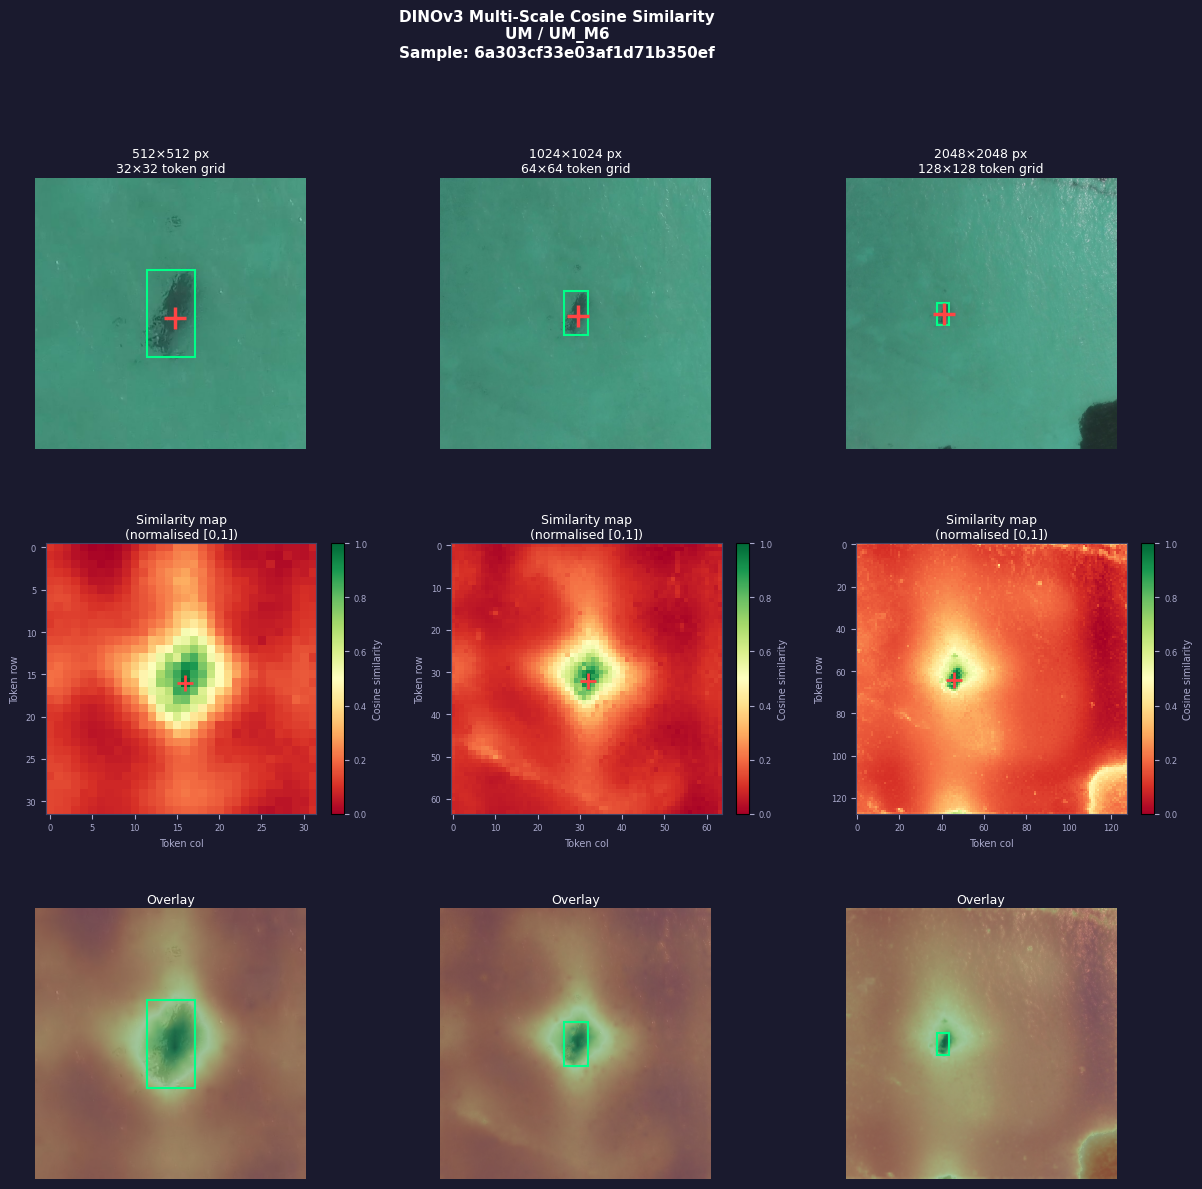

In [24]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350ef",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test3_cosine.jpeg",
)

In [ ]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350b5",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test2_cosine.jpeg",
)

In [ ]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350c4",
    crop_sizes = [512, 1024, 2048],       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
   save_path  = "test_cosine4.jpeg",
)

In [ ]:
#  Call it
# Replace with a real sample_id or filepath from your dataset
fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350a9",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test_cosine.jpeg",
)

# Tiling grid schema analysis

In [6]:
from src.tiling import add_roi_grid

In [61]:
nc_dataset  = fo.load_dataset("nc765")

In [25]:
fo.list_datasets()

['FLPLAN', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [3]:
dataset = fo.load_dataset("wp125")

In [4]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [5]:
import fiftyone.utils.image as foui


In [66]:
thumbnail_dir = "/share/home/e2406743/dataset/dataset/NC/thumb_dir"
foui.transform_images(
    nc_dataset,
    size=(400, 400),              # fixed 400x400 grid thumbnails
    output_field="thumbnail_path",
    output_dir=thumbnail_dir,
    update_filepaths=True,
)

# Tell the App to use thumbnails in the grid, full image on click
dataset.app_config.media_fields     = ["filepath", "thumbnail_path"]
dataset.app_config.grid_media_field = "thumbnail_path"
dataset.app_config.media_fallback   = True   # fall back to filepath if thumb missing
dataset.save()

 100% |█████████████████| 716/716 [6.6s elapsed, 0s remaining, 219.1 samples/s]      


In [67]:
nc_dataset

Name:        nc765
Media type:  image
Num samples: 716
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField

In [5]:
import sys
%load_ext autoreload
%autoreload 2

In [60]:
fo.delete_dataset("nc765")

In [6]:
from src.relabel_calf import relabel_calves, relabel_calves_wp

In [28]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [8]:
relabel_calves_wp(
    dataset=dataset,
    xlsx_path="/share/home/e2406743/dataset/dataset/WP/dugong_environmental_variables_WP.xlsx",
    field_ground="ground_truth",
    new_field="ground_truthv2",
)

Matching mode: (cx, cy) centroid-only -- width/height NOT in metadata
Loaded 3615 rows across 2039 unique label files.
 100% |█████████████████| 152/152 [7.7s elapsed, 0s remaining, 27.4 samples/s]      

Done.
  New field created       : 'ground_truthv2'
  Samples with relabeling : 77
  Detections relabeled     : 79
  Samples copied unchanged (no metadata match): 0
  Samples with empty/None 'ground_truth' (skipped entirely): 0

  --- First 4 examples for debugging ---
    [NO_COORD_MATCH (closest diff=0.41142)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_53'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.13623)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_56'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.19565)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_55'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.29784)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_54'  n_detections=1  n_csv_r

In [ ]:
session = fo.launch_app(dataset, auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [72]:
import pandas as pd
df = pd.read_csv("/share/home/e2406743/dataset/dataset/NC/dugong_environmental_variables_NC.csv")

In [9]:
dataset.count_values("ground_truthv2.detections.label")

{'Dugong': 183, 'calf': 79}

In [92]:
nc_dataset.first()

<Sample: {
    'id': '6a317f84cb12dcb400c28466',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 16, 16, 53, 24, 341000),
    'last_modified_at': datetime.datetime(2026, 6, 16, 17, 23, 44, 36000),
    'region': 'NC',
    'mission_name': 'Flight_226',
    'parent_name': 'Flight_226',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a317f82cb12dcb400c2768c',
                'attributes': {},
                'tags': [],
                'label': 'dugong',
                'bounding_box': [
                    0.9090236686390533,
                    0.29539473684210527,
                    0.01257396449704142,

In [50]:
fo.delete_dataset("dugong")

In [49]:
fo.list_datasets()

['FLPLAN', 'dugong', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [48]:
nc_dataset.values("filepath")

['/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_96.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_93.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_94.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_95.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_805.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH074218-619229147431c_1326.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH034218-619227cbdc2f7_1037.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_1980.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_807.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH

In [8]:
dataset = fo.load_dataset("wp125")

In [35]:
add_roi_grid(dataset, 
             field_name = "roigrid_2048_250",
                tile_size=2048, 
                overlap=250)

Adding 'roigrid_2048_250' (tile=2048px, overlap=250px) ...
 100% |█████████████████| 152/152 [4.6s elapsed, 0s remaining, 30.6 samples/s]      
  'roigrid_2048_250' added to 152 samples (12 tiles/image at this resolution).


In [36]:
sample = dataset.first()
sample.field_names

('id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'region',
 'mission_name',
 'parent_name',
 'ground_truth',
 'thumbnail_path',
 'roigrid_512_250',
 'roigrid_1024_250',
 'roigrid_2048_250')

In [42]:
len(sample.roigrid_512_250.detections)

294

In [43]:
len(sample.roigrid_1024_250.detections)

40

In [44]:
len(sample.roigrid_2048_250.detections)

12

In [31]:
dataset.delete_sample_fields(["roi_grid","roigrid_2048_250","roigrid_1024_250","roigrid_512_250"])

In [20]:
dataset.count('roi_grid.detections')

2486

In [37]:
dataset.count('roigrid_512_250.detections')

24720

In [38]:
dataset.count('roigrid_1024_250.detections')

3128

In [ ]:
dataset.count('roigrid_2048_250.detections')

996

In [41]:
len(sample.roigrid_512_250.detections)

294

# Embeddings at the full image 

In [2]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout
import numpy as np 

In [3]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [4]:
dataset = fo.load_dataset("wp_final_test")

In [44]:
dataset

Name:        tiles2048_merged
Media type:  image
Num samples: 1540
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.field

In [7]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)



Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [9]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 1024,
    "width": 1024
  }
}

In [8]:
# Change resize target from 224x224 to e.g. 448x448 or 512x512
processor.size = {"height": 1024, "width": 1024}
# processor.do_resize stays True -- we WANT resizing here, just to a bigger target

print(processor.size)  # confirm: {'height': 448, 'width': 448}

{'height': 1024, 'width': 1024}


In [31]:
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
processor.size = {"height": 1024, "width": 1024}   # matches tile_size exactly

# Sanity check: feed a real 1024x1024 tile through and confirm no resize happened
from PIL import Image
import numpy as np

dummy = Image.fromarray(np.zeros((1024, 1024, 3), dtype=np.uint8))
out   = processor(images=dummy, return_tensors="pt")
print(out["pixel_values"].shape)   # expect (1, 3, 1024, 1024)

assert out["pixel_values"].shape[-2:] == (1024, 1024), (
    "Processor is NOT preserving native 1024x1024 -- check do_resize/size."
)

torch.Size([1, 3, 1024, 1024])


In [47]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 2048,
    "width": 2048
  }
}

In [10]:
dataset.list_saved_views()

['positive', 'train_view', 'test_view']

In [11]:
positive  = dataset.load_saved_view("positive")
train_view = dataset.load_saved_view("train_view")

In [18]:
## Here I compute the embedding for the full image 
embeddings = train_view.compute_embeddings(
    model,
    embeddings_field=None,
    num_workers =2,
    batch_size=4,
    progress=True,  
)

 100% |█████████████████| 219/219 [3.1s elapsed, 0s remaining, 75.4 samples/s]       


In [19]:
embeddings.shape

(219, 1024)

In [15]:
from pathlib import Path
import os

In [20]:
sample_ids_list = np.array(train_view.values("id"))
stem_list = np.array([Path(f).stem for f in train_view.values("filepath")])


## save 
folder_emb = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3"
out_file = "train_positive_UM_1024_embeddings.npz"

np.savez_compressed(
    os.path.join(folder_emb,out_file),
    embeddings = embeddings,
    sample_ids = sample_ids_list,
    stem_filepath = stem_list
)

In [52]:
sample_ids_list = np.array(dataset.values("id"))
stem_list = np.array([Path(f).stem for f in dataset.values("filepath")])


In [53]:
stem_list.shape

(1540,)

In [54]:
folder_emb = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3"
out_file = "merged_2048o224_WPandUMnoNC_embeddings.npz"

np.savez_compressed(
    os.path.join(folder_emb,out_file),
    embeddings = embeddings,
    sample_ids = sample_ids_list,
    stem_filepath = stem_list
)

In [ ]:
## compute visualization 
# Step 3: visualization, reusing the SAME in-memory dict (not the npz)
fob.compute_visualization(
    dataset,
    embeddings=embeddings,   # dict, keyed by sample_id -> reused directly
    method="tsne",
    brain_key="tsnev1",
    create_index=True,
    seed=42,
    max_iter=500,
    progress=True,
)

Generating visualization...


dataset

### COmpute visualization of tiles

In [37]:
import numpy as np 
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [35]:
# ── Load saved embeddings and compute 2D projections by hand ────────────────
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
import umap

data        = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz")
embeddings  = data["embeddings"]
sample_ids  = data["sample_ids"]

print(embeddings.shape)
embeddings_norm = normalize(embeddings, norm="l2")

# UMAP
reducer = umap.UMAP(
    n_neighbors=30, n_epochs=500, min_dist=0.2,
    metric="cosine", init="pca", random_state=42,
)
coords_2d_umap = reducer.fit_transform(embeddings_norm)

# # t-SNE
# tsne = TSNE(
#     n_components=2, random_state=0, perplexity=30,
#     metric="cosine", init="pca",
# )
# coords_2d_tsne = tsne.fit_transform(embeddings_norm)

# print(f"sample_ids: {sample_ids.shape}  coords_2d_umap: {coords_2d_umap.shape}  coords_2d_tsne: {coords_2d_tsne.shape}")

(11123, 1024)


/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [39]:
# ── Feed the hand-computed UMAP coords into FiftyOne, skipping its own reduction ──
fob.compute_visualization(
    dataset,
    points=coords_2d_umap,        # pre-computed 2D coords, NOT embeddings=...
    sample_ids=sample_ids,        # explicit row-order join key
    brain_key="umap",
    create_index=True,
)

Generating spatial index in field 'umap'...
 100% |█████████████| 11123/11123 [556.7ms elapsed, 0s remaining, 20.1K samples/s]      


# patch embeddings

In [ ]:
# model 
import fiftyone.core.models as fom

class DinoV3PatchModel(fom.Model):

    def __init__(self, model, processor, device=None):
        self.model = model
        self.processor = processor
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()

    @property
    def media_type(self):
        return "image"

    @property
    def has_logits(self):
        return False

    @property
    def has_embeddings(self):
        return True

    @property
    def ragged_batches(self):
        return False

    @property
    def transforms(self):
        return None  # Let embed() handle everything

    def _preprocess(self, img):
        """Convert any input format to a processor-ready PIL image."""
        from PIL import Image
        import numpy as np
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()
        if isinstance(img, np.ndarray):
            if img.dtype != np.uint8:
                img = (img * 255).clip(0, 255).astype(np.uint8)
            img = Image.fromarray(img)
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        return img.convert("RGB")

    def embed(self, img):
        pil = self._preprocess(img)
        inputs = self.processor(images=pil, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (1, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.squeeze(0).cpu().numpy()

    def embed_all(self, imgs):
        from PIL import Image
        pil_imgs = [self._preprocess(img) for img in imgs]
        inputs = self.processor(images=pil_imgs, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (B, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.cpu().numpy()




In [ ]:
model = DinoV3PatchModel(base_model, processor)

In [ ]:
# resizes the processor 
# Change resize target from 224x224 to e.g. 448x448 or 512x512
processor.size = {"height": 124, "width": 124}
# processor.do_resize stays True -- we WANT resizing here, just to a bigger target

print(processor.size)  # confirm: {'height': 448, 'width': 448}

In [ ]:
# plot some patches 
from src.plot_patches_grid import plot_patches

# Random 9 patches -> 3x3 grid
plot_patches(dataset, patches_field="ground_truth", num_objects=9, seed=42)

# # Explicit list, e.g. straight from to_patches()
# pairs = [(s.sample_id, s.id) for s in dataset.to_patches("ground_truth").take(6)]
# plot_patches(dataset, patches_field="ground_truth", patch_list=pairs)

# # Or directly from your saved object_embeddings npz (detection_ids + sample_ids)
# data = np.load("nc_object_embeddings.npz")
# pairs = list(zip(data["sample_ids"][:9], data["detection_ids"][:9]))
# plot_patches(dataset, patches_field="ground_truth", patch_list=pairs)

In [ ]:
# ── Investigate what actually happens to one real patch crop ────────────────
import numpy as np
from PIL import Image

# Pick one real, non-square detection from your dataset
sample = dataset.match(F(f"{PATCHES_FIELD}.detections").length() > 0).first()
detection = sample[PATCHES_FIELD].detections[0]

with Image.open(sample.filepath) as img:
    img_w, img_h = img.size
    bx, by, bw, bh = detection.bounding_box
    x1, y1 = int(bx * img_w), int(by * img_h)
    x2, y2 = int((bx + bw) * img_w), int((by + bh) * img_h)
    crop = img.convert("RGB").crop((x1, y1, x2, y2))

print(f"Original crop size (W x H): {crop.size}")
print(f"Aspect ratio: {crop.size[0] / crop.size[1]:.3f}")

# Run it through the EXACT processor your model uses
print(f"\nProcessor config:")
print(f"  do_resize        : {processor.do_resize}")
print(f"  size              : {processor.size}")
print(f"  default_to_square : {processor.default_to_square}")

inputs = processor(images=crop, return_tensors="pt")
print(f"\nTensor shape AFTER processor: {tuple(inputs['pixel_values'].shape)}")
print(f"(channels, height, width)")

In [ ]:
# ── Object-level (patch) embedding extraction for ONE dataset ──────────────
# NOTE: these are PATCH/OBJECT embeddings (one per ground_truth detection,
# i.e. per dugong/calf crop) -- NOT full-image embeddings. Each row in the
# saved .npz corresponds to exactly one fo.Detection, uniquely identified
# by that detection's own .id (robust even if detection order changes).

import numpy as np

PATCHES_FIELD = "ground_truth"
OUTPUT_NPZ    = "nc_object_embeddings.npz"   # <- rename per dataset (nc/wp/um)
BRAIN_KEY     = "object_emb_dinov3_tsne_nc"  # <- rename per dataset

# Step 1: compute OBJECT (patch) embeddings, NOT written to the dataset
# Returns: {sample_id: np.ndarray(num_detections_in_that_sample, dim)}
object_embeddings = dataset.compute_patch_embeddings(
    model,
    patches_field=PATCHES_FIELD,
    num_workers=0,
    progress=True,
    # embeddings_field intentionally omitted -> nothing written to MongoDB
)

# Step 2: flatten to (total_objects, dim), join key = each Detection's own .id
detection_ids, sample_ids, rows = [], [], []
for sample_id, arr in object_embeddings.items():
    detections = dataset[sample_id][PATCHES_FIELD].detections
    assert len(detections) == arr.shape[0], (
        f"Mismatch for sample {sample_id}: {len(detections)} detections "
        f"vs {arr.shape[0]} embedding rows"
    )
    for det, vec in zip(detections, arr):
        detection_ids.append(det.id)     # unique per-object join key
        sample_ids.append(sample_id)     # which image this object came from
        rows.append(vec)

object_embeddings_flat = np.stack(rows, axis=0)         # (total_objects, dim)
detection_ids = np.array(detection_ids)                  # join key -> ground_truth.detections[i].id
sample_ids    = np.array(sample_ids)                     # which sample/image

np.savez_compressed(
    OUTPUT_NPZ,
    object_embeddings=object_embeddings_flat,   # (total_objects, dim) float32
    detection_ids=detection_ids,                # unique per-object ID (join key)
    sample_ids=sample_ids,                      # parent image's sample_id
)
print(f"Saved {object_embeddings_flat.shape[0]} object embeddings "
      f"({object_embeddings_flat.shape[1]}-dim) -> '{OUTPUT_NPZ}'")

# Step 3: visualization, reusing the SAME in-memory dict (not the npz)
fob.compute_visualization(
    dataset,
    patches_field=PATCHES_FIELD,
    embeddings=object_embeddings,   # dict, keyed by sample_id -> reused directly
    method="tsne",
    brain_key=BRAIN_KEY,
    create_index=True,
    seed=42,
    max_iter=2000,
    progress=True,
)
print(f"Visualization stored under brain_key '{BRAIN_KEY}'.")

# Compute Visualization

 np.saved

In [2]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [18]:
dataset = fo.load_dataset("tiles_merged")
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [51]:
dataset.count_values("mission_name")

{'UM': 83}

In [36]:
dataset.count_values("parent_name")

{'Flight_197': 50,
 'Flight_233': 6,
 'Flight_226': 5,
 'Flight_212': 36,
 'Flight_215': 37,
 'Flight_232': 23,
 'Flight_234': 2,
 'Flight_199': 8,
 'Flight_213': 41,
 'Flight_235': 4,
 'Flight_209': 83,
 'Flight_231': 12,
 'Flight_214': 19,
 'Flight_195': 6,
 'Flight_225': 2,
 'Flight_200': 10,
 'Flight_196': 63,
 'Flight_207': 128,
 'Flight_220': 20,
 'Flight_205': 9,
 'Flight_211': 17,
 'Flight_218': 22,
 'Flight_198': 73,
 'Flight_222': 17,
 'Flight_219': 23}

In [8]:
dataset.count_values("parent_name")

{'Flight_195': 48,
 'Flight_235': 32,
 'Flight_232': 184,
 'FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09': 70,
 'FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10': 210,
 'FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_26_03_10': 385,
 'FPLAN_M4_UM_M40_F1_2025_P_1-69983452bef98_26_03_10': 35,
 'UM_M2': 210,
 'Flight_198': 584,
 'FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_26_03_09': 280,
 'GAM_M10': 60,
 'Flight_214': 152,
 'Flight_231': 96,
 'Flight_225': 16,
 'Flight_220': 160,
 'Flight_212': 288,
 'Flight_209': 664,
 'Flight_199': 64,
 'FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_26_03_09': 35,
 'FRIWEN_M53': 60,
 'FRIWEN_M11': 360,
 'FRIWEN_M12': 165,
 'FPLAN_M4_UM_M13_F1_2025_P_4-6973e124ed55b_26_03_09': 245,
 'FPLAN_P4P_UM_M33_F1_2025_GSP-697b1d86c5e8c_26_03_09': 315,
 'GAM_M2': 165,
 'FPLAN_M4_UM_M40_F1_2025_P_2-699839d1afc67_26_03_10': 140,
 'FPLAN_M4_UM_M46_F1_2025_P_3-699848dc6accc_26_03_10': 175,
 'FPLAN_P4_UM_M35_F1_2025_GSP-69970e580c6f4_26_03_10': 200,
 'Flight_222': 136,


In [16]:
dataset.count_values("region")

{'NC': 716}

In [6]:
dataset.count_values("subregion")

{'UM': 3940, 'MANTASANDY': 105, 'NC': 5728, 'GAM': 405, 'FRIWEN': 945}

In [8]:
map_name_plot = {
    "UM":"D",
    "MANTASANDY":"C",
    "NC":"NC",
    "GAM":"B",
    "FRIWEN":"A"
}
for sample in dataset.iter_samples(progress=True):
    subregion = sample['subregion']
    new_name = map_name_plot[subregion]
    sample['subregion_plot'] = new_name
    sample.save()

 100% |█████████████| 11123/11123 [7.4s elapsed, 0s remaining, 1.6K samples/s]        


In [24]:
dataset.select_fields("region")

Dataset:     nc765
Media type:  image
Num samples: 716
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
View stages:
    1. SelectFields(field_names=['region'], meta_filter=None)

In [19]:
import numpy as np 
def load_and_tag(npz_path, dataset_name, field_name_region, field_name_subregion):
    """Load the npz files and provide associate metadata query from fiftyone.dataset

    args:
        dataset_name :Name of fiftyone mongod dataset
        field_name_subgion: Name of the field to retrieve the subregion
    """

    data = np.load(npz_path)
    n = data["embeddings"].shape[0]
    sample_ids = data["sample_ids"]

    # Re-derive subregion (mission_name) by querying FiftyOne directly,
    dataset = fo.load_dataset(dataset_name)
    print(dataset.name)
    ids_list = np.array(dataset.values("id"))
    query_region = np.array(dataset.values(field_name_region))
    query_subregion = np.array(dataset.values(field_name_subregion))

    assert all(ids_list == sample_ids), f"Problem of alignment of ids. BIG ISSUES"


    return {
        "embeddings": data["embeddings"],
        "sample_ids": sample_ids,
       # "stems":      data["stems_filepaths"],
        "region":     query_region,
        "subregion":  query_subregion,
    }


In [20]:
dataset.first()

<Sample: {
    'id': '6a33c2d08be790ca1e89a2ac',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH014205-611f8c7997ea4_1808__tile_0_800_t1024_o224.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 90472,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 18, 11, 29, 1, 457000),
    'last_modified_at': datetime.datetime(2026, 7, 17, 9, 8, 7, 201000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33c2c48be790ca1e898130',
                'attributes': {},
                'tags': [],
                'label': '1',
                'bounding_box': [0.4365234375, 0.0556640625, 0.04296875, 0.046875],
                'mask': None,
                'mask_path': None,
                'confidence': None,
         

In [36]:
full_merged = load_and_tag(
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz",
    "tiles_merged",
    "region",
    "uniqueness_score"
)

tiles_merged


In [ ]:
emb_nc = load_and_tag("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/nc_full_embeddings.npz",
                      region_name="NC",
                      dataset_name="nc765",
                      field_name_subregion="subregion_plot")

emb_wp = load_and_tag(npz_path="/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/wp_full_embeddings.npz",
                      region_name="WP", 
                      dataset_name="wp125",
                      field_name_subregion="subregion_plot")

emb_um = load_and_tag("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/um_flplan_full_embeddings.npz",
                      "UM", 
                      "FLPLAN",
                      "subregion_plot")


In [ ]:
## join them
sources = [emb_nc, emb_wp, emb_um]
full_merged = np.concatenate([s["embeddings"] for s in sources], axis=0)
joint_sample_ids = np.concatenate([s["sample_ids"] for s in sources], axis=0)
joint_region     = np.concatenate([s["region"]     for s in sources], axis=0)
joint_subregion  = np.concatenate([s["subregion"]  for s in sources], axis=0)

print(f"Joint embeddings: {full_merged.shape}")
print(f"Region counts:    {dict(zip(*np.unique(joint_region, return_counts=True)))}")
print(f"Subregion counts: {dict(zip(*np.unique(joint_subregion, return_counts=True)))}")

Joint embeddings: (951, 1024)
Region counts:    {np.str_('NC'): np.int64(716), np.str_('UM'): np.int64(83), np.str_('WP'): np.int64(152)}
Subregion counts: {np.str_('FRIWEN'): np.int64(63), np.str_('GAM'): np.int64(27), np.str_('MANTASANDY'): np.int64(3), np.str_('NC'): np.int64(716), np.str_('UM'): np.int64(142)}


In [27]:
from sklearn.manifold import TSNE
print(f"embeddings: {full_merged['embeddings'].shape}")
print(f"Region counts:    {dict(zip(*np.unique(full_merged['region'], return_counts=True)))}")
print(f"Subregion counts: {dict(zip(*np.unique(full_merged['subregion'], return_counts=True)))}")


from sklearn.preprocessing import normalize
 
full_merged_norm = normalize(full_merged['embeddings'], norm="l2")
 
tsne = TSNE(
    n_components=2, 
    random_state=0, 
    perplexity=99,
    metric="cosine", 
    init="pca",
)
coords_2d_tsne = tsne.fit_transform(full_merged_norm)

embeddings: (11123, 1024)
Region counts:    {np.str_('NC'): np.int64(5728), np.str_('WP'): np.int64(5395)}
Subregion counts: {np.float64(0.0): np.int64(1037), np.float64(1.0): np.int64(331), np.float64(2.0): np.int64(1210), np.float64(3.0): np.int64(509), np.float64(4.0): np.int64(632), np.float64(5.0): np.int64(838), np.float64(6.0): np.int64(673), np.float64(7.0): np.int64(365), np.float64(8.0): np.int64(1142), np.float64(9.0): np.int64(887), np.float64(10.0): np.int64(1205), np.float64(11.0): np.int64(609), np.float64(12.0): np.int64(362), np.float64(13.0): np.int64(896), np.float64(14.0): np.int64(427)}


In [23]:
import pandas as pd
cluster_labels = dataset.values("cluster_label")
pd.Series(cluster_labels).unique()

array([ 5.,  6., 11.,  2., 14.,  9., 12., 13.,  1.,  0.,  7.,  4.,  3.,
        8., 10.])

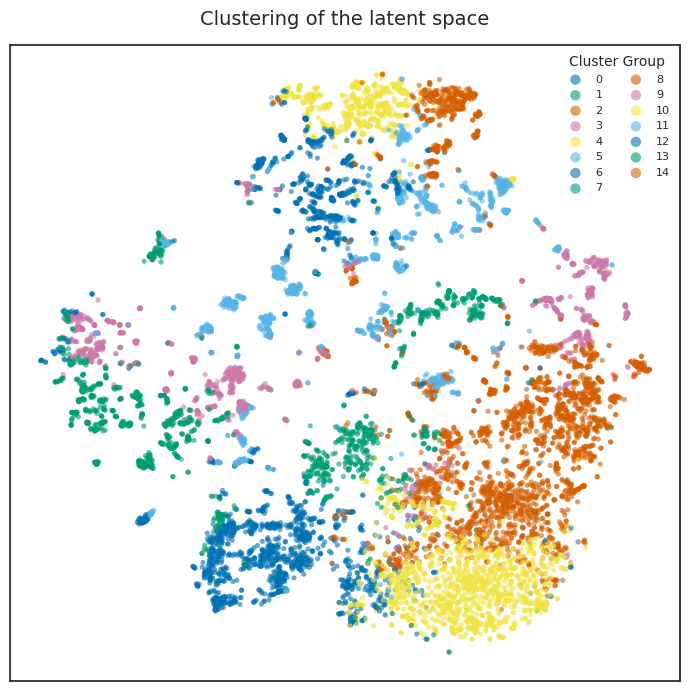

In [35]:
color_labels = full_merged['subregion']   # cluster label floats per sample

with plt.style.context('seaborn-v0_8-white'):
    unique_labels = sorted(set(color_labels))
    # Build palette from actual unique cluster labels in the data
    cycle_colors  = [d["color"] for d in plt.rcParams["axes.prop_cycle"]]
    palette = {
        lab: cycle_colors[i % len(cycle_colors)]
        for i, lab in enumerate(unique_labels)
    }

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    for lab in unique_labels:
        mask = color_labels == lab           # <- = not ==
        ax.scatter(
            coords_2d_tsne[mask, 0], coords_2d_tsne[mask, 1],
            s=14, alpha=0.6, color=palette[lab], label=str(int(lab)),
            edgecolors="none",
        )

    #ax.set_title("Clustering", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=2, title="Cluster Group", ncol=2)
    fig.suptitle("Clustering of the latent space", fontsize=14, 
                 #fontweight="bold"
                 )
    plt.tight_layout()
    plt.show()

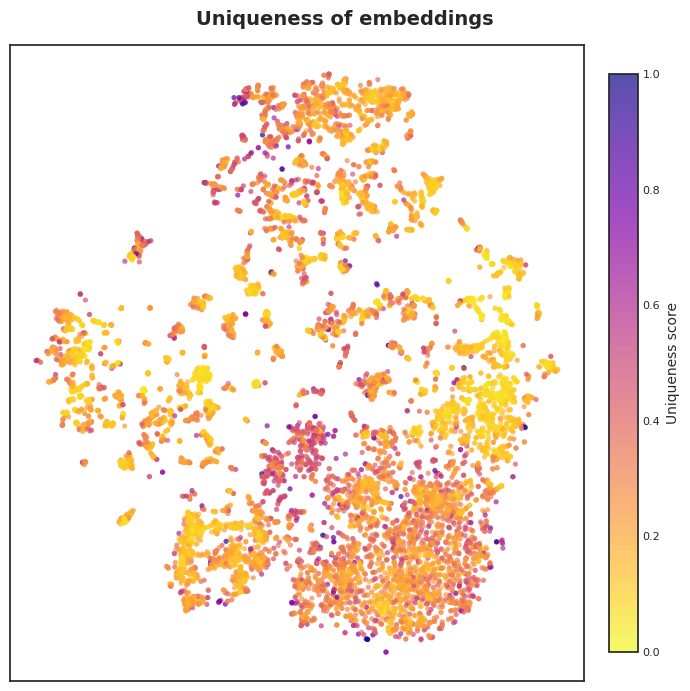

In [40]:
uniqueness_values = full_merged['subregion']   # contains uniqueness scores [0,1]

with plt.style.context('seaborn-v0_8-white'):
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    sc = ax.scatter(
        coords_2d_tsne[:, 0], coords_2d_tsne[:, 1],
        c=uniqueness_values,
        cmap="plasma_r",        # perceptually uniform, works well for [0,1] range
        vmin=0.0, vmax=1.0,
        s=14, alpha=0.7,
        edgecolors="none",
    )

    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Uniqueness score", fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    #ax.set_title("Uniqueness", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.suptitle("Uniqueness of embeddings", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

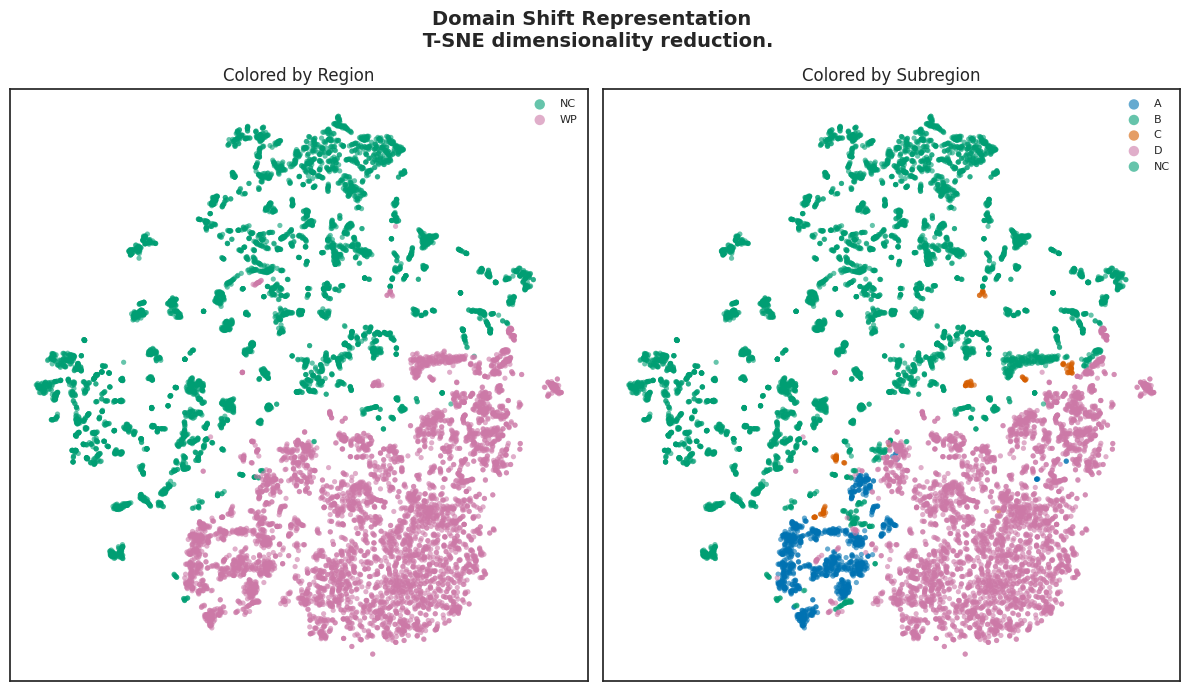

In [39]:
# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [full_merged['region'], full_merged['subregion']], ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_tsne[mask, 0], coords_2d_tsne[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)
        #ax.annotate('figure pixels',xy=(0,0),y=(0, 0))

    fig.suptitle("Domain Shift Representation \n T-SNE dimensionality reduction.", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [21]:
import sys
%load_ext autoreload
%autoreload 2

# import sys
# sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")


In [23]:
import matplotlib.pyplot as plt
plt.style.available


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [31]:
import sys
%load_ext autoreload
%autoreload 2

# import sys
# sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
full_merged_norm = normalize(full_merged, norm="l2")
 
pca_2d = PCA(n_components=5)
coords_2d_pca = pca_2d.fit_transform(full_merged_norm)
 
 
pca_2d.explained_variance_ratio_

array([0.16408738, 0.13287127, 0.0703226 , 0.06058995, 0.04302573],
      dtype=float32)

/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


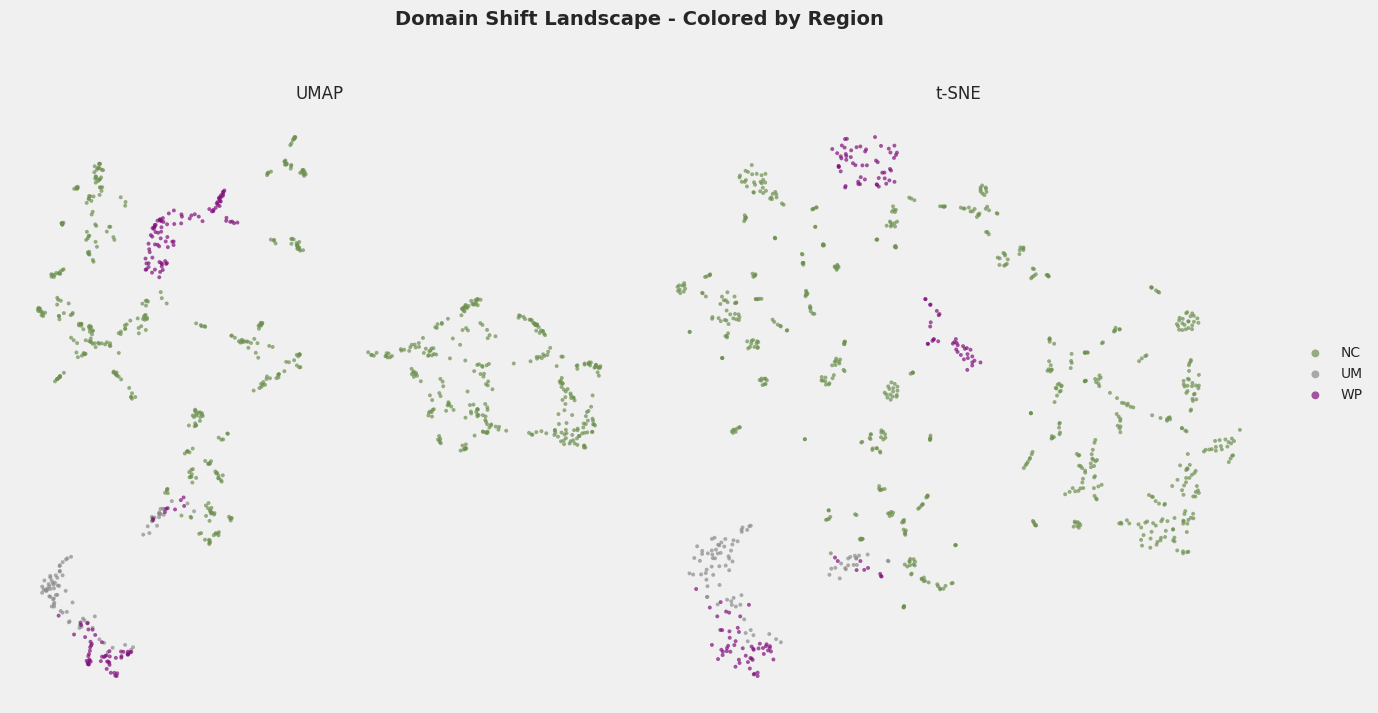

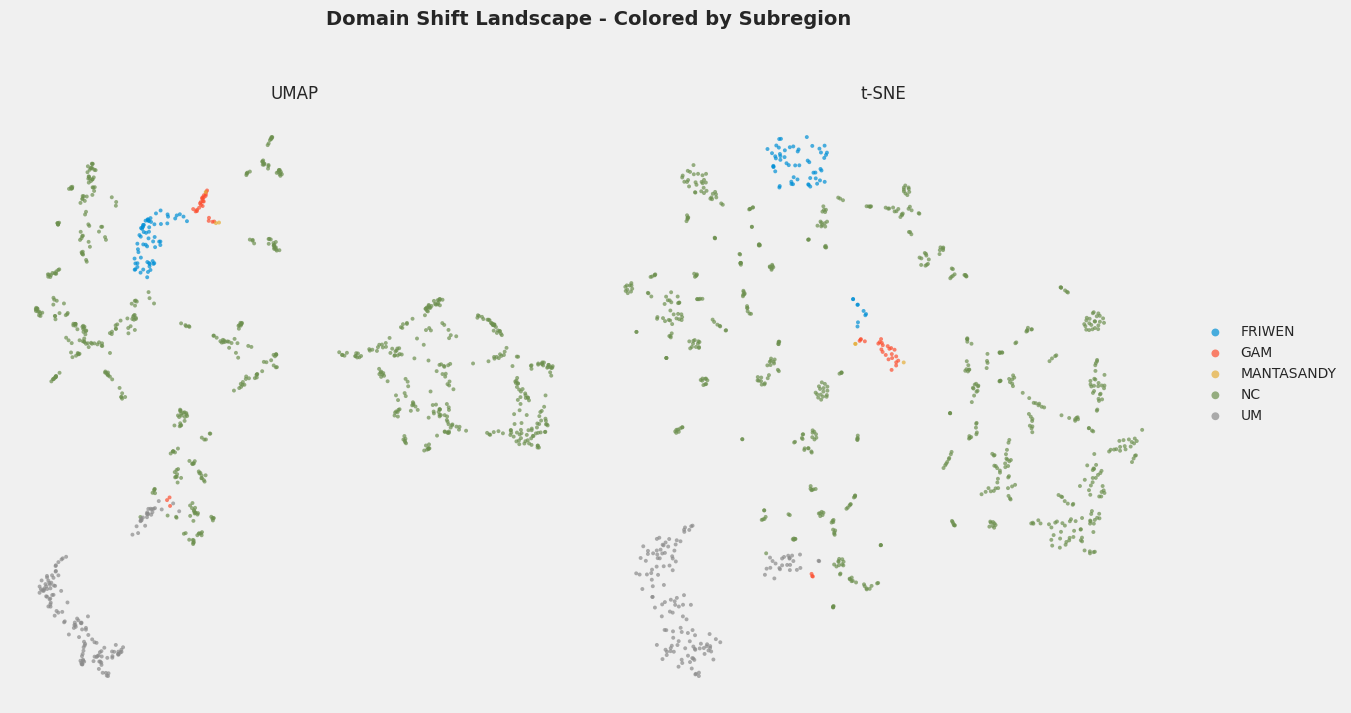

In [ ]:
# ── Compute the three 2D projections on the joint embeddings ────────────────
# (Normalise first -- cosine-based methods and PCA both benefit from this)
from sklearn.preprocessing import normalize
 
full_merged_norm = normalize(full_merged, norm="l2")
 
pca_2d = PCA(n_components=2)
coords_2d_pca = pca_2d.fit_transform(full_merged_norm)
 
reducer = umap.UMAP(
    n_neighbors=30, n_epochs=500, min_dist=0.2,
    metric="cosine", init="pca", random_state=42,
)
coords_2d_umap = reducer.fit_transform(full_merged_norm)
 
tsne = TSNE(
    n_components=2, random_state=0, perplexity=30,
    metric="cosine", init="pca",
)
coords_2d_tsne = tsne.fit_transform(full_merged_norm)
 
# ── Plot, colored by region ───────────────────────────────────────────────
fig_region = plot_domain_shift_landscape(
    coords_2d_pca, coords_2d_umap, coords_2d_tsne,
    color_labels=joint_region,
    figsize=(13,7),
    title="Domain Shift Landscape - Colored by Region",
)
plt.show()
 
# ── Plot, colored by subregion ────────────────────────────────────────────
fig_subregion = plot_domain_shift_landscape(
    coords_2d_pca, coords_2d_umap, coords_2d_tsne,
    color_labels=joint_subregion,
    figsize=(12,7),
    title="Domain Shift Landscape - Colored by Subregion",
)
plt.show()

## Plot with different style 

In [4]:
import sys
%load_ext autoreload
%autoreload 2

In [7]:
import matplotlib.pyplot as plt
print(plt.rcParams['axes.facecolor'])   # ggplot's light gray, e.g. '#E5E5E5' or similar
print(plt.style.available)               # confirm 'ggplot' is a valid name in this matplotlib version

white
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [12]:

# Apply the ggplot style globally for the session
# (Change this freely to test other styles, e.g. 'bmh', 'fivethirtyeight',
#  'tableau-colorblind10', 'Solarize_Light2' -- see plt.style.available)
plt.style.use('seaborn-v0_8-colorblind')
 
# Every label that could ever appear across any plot (region OR subregion)
# is registered here ONCE, so the same label always maps to the same
# position in the color cycle -- guaranteeing e.g. "NC" gets the same
# color in every figure, regardless of which subset of labels is present
# in a given call, and regardless of which style is currently active.
ALL_REGION_LABELS    = ["NC", "WP", "UM"]
ALL_SUBREGION_LABELS = ["FRIWEN", "GAM", "MANTASANDY", "UM","A","B","C","D"]   # extend as needed
_ALL_LABELS = sorted(set(ALL_REGION_LABELS) | set(ALL_SUBREGION_LABELS))
 
 
def _build_palette_from_active_style(labels):
    """
    Builds a {label: color} mapping by pulling colors directly from the
    CURRENTLY ACTIVE style's axes.prop_cycle, rather than hardcoding a
    colormap like tab10. This means the palette automatically follows
    whatever style is active via plt.style.use(...) at call time -- so
    switching styles between cells changes the palette too, without
    needing to touch this function.
 
    If there are more labels than colors in the cycle, colors repeat
    (wrap around) rather than erroring, since some styles (e.g. ggplot)
    have fewer built-in colors than others (e.g. tab10-based cycles).
    """
    cycle_colors = [d["color"] for d in plt.rcParams["axes.prop_cycle"]]
    return {
        lab: cycle_colors[i % len(cycle_colors)]
        for i, lab in enumerate(labels)
    }
 
 
# Built fresh from whichever style is active at import time. Call
# _build_palette_from_active_style(_ALL_LABELS) again after switching
# styles if you want GLOBAL_PALETTE to reflect the new style too.
GLOBAL_PALETTE = _build_palette_from_active_style(_ALL_LABELS)

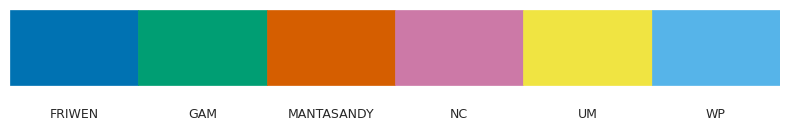

In [54]:
fig, ax = plt.subplots(figsize=(8, 1.5))

for i, (label, color) in enumerate(GLOBAL_PALETTE.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.3, label, ha="center", va="top", fontsize=9)

ax.set_xlim(0, len(GLOBAL_PALETTE))
ax.set_ylim(-0.6, 1)
ax.axis("off")
#ax.set_title(f"Palette ({current_style_name})", fontsize=10)
plt.tight_layout()
plt.show()

In [42]:
GLOBAL_PALETTE

{'FRIWEN': '#E24A33',
 'GAM': '#348ABD',
 'MANTASANDY': '#988ED5',
 'NC': '#777777',
 'UM': '#FBC15E',
 'WP': '#8EBA42'}

In [55]:
print(plt.rcParams['axes.facecolor'])   # ggplot's light gray, e.g. '#E5E5E5' or similar
print(plt.style.available)               # confirm 'ggplot' is a valid name in this matplotlib version

#E5E5E5
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


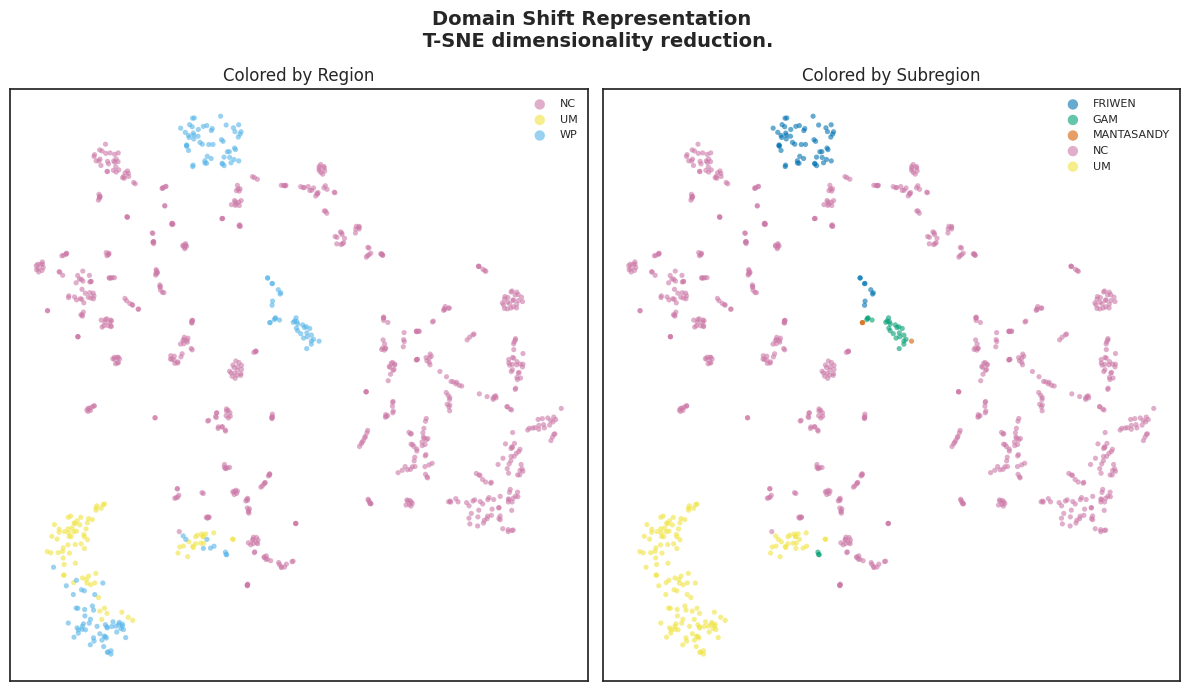

In [67]:
# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [joint_region, joint_subregion], ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_tsne[mask, 0], coords_2d_tsne[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)
        #ax.annotate('figure pixels',xy=(0,0),y=(0, 0))

    fig.suptitle("Domain Shift Representation \n T-SNE dimensionality reduction.", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

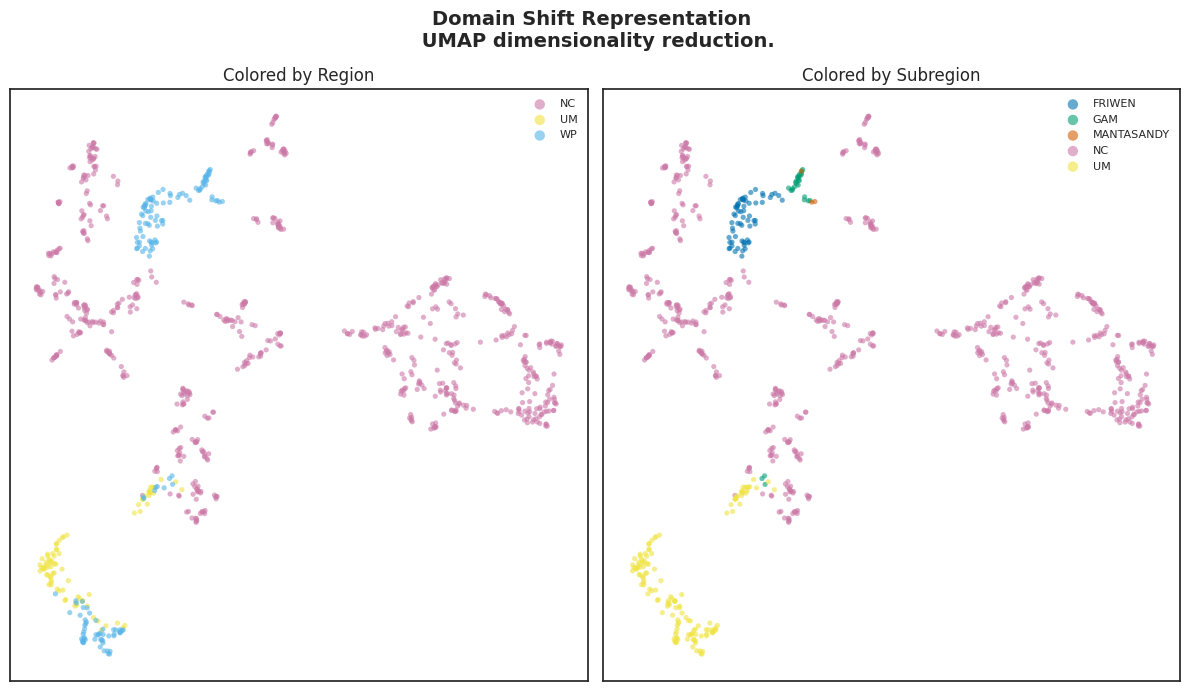

In [68]:
# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [joint_region, joint_subregion], ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_umap[mask, 0], coords_2d_umap[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)
        #ax.annotate('figure pixels',xy=(0,0),y=(0, 0))

    fig.suptitle("Domain Shift Representation \n UMAP dimensionality reduction.", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
# ── 3D UMAP, colored by subregion, hover shows region too ──────────────────
import plotly.express as px
import pandas as pd
import umap

# Fit UMAP in 3D (separate from the earlier 2D fit)
reducer_3d = umap.UMAP(
    n_neighbors=45, n_epochs=500, min_dist=0.25,
    metric="cosine", init="pca", n_components=3, random_state=23,
)
coords_3d_umap = reducer_3d.fit_transform(full_merged_norm)

# Build a small dataframe so plotly can use named columns for color/hover
df_plot = pd.DataFrame({
    "x": coords_3d_umap[:, 0],
    "y": coords_3d_umap[:, 1],
    "z": coords_3d_umap[:, 2],
    "subregion": joint_subregion,
    "region": joint_region,
})

fig = px.scatter_3d(
    df_plot,
    x="x", y="y", z="z",
    color="subregion",
    hover_data={"region": True, "x": False, "y": False, "z": False},
    title="3D UMAP - Domain Shift Landscape (colored by subregion)",
    opacity=0.7,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(xaxis_title="UMAP-1", yaxis_title="UMAP-2", zaxis_title="UMAP-3"),
    legend_title_text="Subregion",
)
fig.show()

/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



### plotting object embeddings

In [8]:
def load_and_tag_objects(
    npz_path,
    dataset_name,
    field_name_region,
    field_name_subregion,
    patches_field="ground_truth",
):
    """
    Load object/patch embeddings npz and attach per-row metadata
    (region, subregion) looked up from FiftyOne via the parent sample_id.

    The object npz has N_objects rows where multiple rows can share the
    same sample_id (one row per detection). Metadata is looked up once
    per unique sample_id then broadcast to all rows belonging to that
    sample -- no per-row FiftyOne query.

    Args
    ----
    npz_path             : path to all_objects_embeddings.npz
    dataset_name         : FiftyOne dataset name
    field_name_region    : sample-level field for region (e.g. "region")
    field_name_subregion : sample-level field for subregion (e.g. "subregion_plot")
    patches_field        : Detections field (used only for informational count)

    Returns
    -------
    dict with keys:
        object_embeddings : (N_objects, 1024)
        detection_ids     : (N_objects,)  -- unique per-object join key
        sample_ids        : (N_objects,)  -- parent sample_id per row
        region            : (N_objects,)  -- one value per row, from parent sample
        subregion         : (N_objects,)  -- one value per row, from parent sample
    """
    data       = np.load(npz_path)
    embeddings = data["object_embeddings"]       # (N, 1024)
    sample_ids = data["sample_ids"]              # (N,) -- repeated for multi-detection tiles
    det_ids    = data["detection_ids"]           # (N,)

    print(f"Loaded {len(embeddings)} object embeddings "
          f"from {np.unique(sample_ids).shape[0]} unique samples.")

    # ── Build lookup {sample_id: (region, subregion)} in ONE FiftyOne query
    dataset = fo.load_dataset(dataset_name)
    print(f"Dataset: {dataset.name}")

    # Fetch only the unique sample_ids present in the npz (not the full dataset)
    unique_sids = np.unique(sample_ids).tolist()
    view = dataset.select(unique_sids).select_fields(
        [field_name_region, field_name_subregion]
    )

    region_lookup    = {}
    subregion_lookup = {}
    for s in view.iter_samples():
        region_lookup[s.id]    = s.get_field(field_name_region)
        subregion_lookup[s.id] = s.get_field(field_name_subregion)

    missing = [sid for sid in unique_sids if sid not in region_lookup]
    if missing:
        print(f"  WARNING: {len(missing)} sample_id(s) from the npz were not "
              f"found in dataset '{dataset_name}' -- those rows will be tagged "
              f"as 'unknown'.")

    # ── Broadcast per-sample metadata to every detection row ─────────────
    region_arr    = np.array([region_lookup.get(sid,    "unknown") for sid in sample_ids])
    subregion_arr = np.array([subregion_lookup.get(sid, "unknown") for sid in sample_ids])

    print(f"Region counts:    {dict(zip(*np.unique(region_arr,    return_counts=True)))}")
    print(f"Subregion counts: {dict(zip(*np.unique(subregion_arr, return_counts=True)))}")

    return {
        "object_embeddings": embeddings,
        "detection_ids":     det_ids,
        "sample_ids":        sample_ids,
        "region":            region_arr,
        "subregion":         subregion_arr,
    }

In [15]:
import numpy as np 
obj = load_and_tag_objects(
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/objects_emb/all_objects_embeddings.npz",
    "tiles_merged",
    "region",
    "subregion_plot",
)

# t-SNE on object embeddings
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE

print(f"Object embeddings: {obj['object_embeddings'].shape}")

obj_norm = normalize(obj["object_embeddings"], norm="l2")

tsne_obj = TSNE(
    n_components=2,
    random_state=0,
    perplexity=50,
    metric="cosine",
    init="pca",
)
coords_2d_tsne_obj = tsne_obj.fit_transform(obj_norm)



Loaded 9265 object embeddings from 2546 unique samples.
Dataset: tiles_merged
Region counts:    {np.str_('NC'): np.int64(8572), np.str_('WP'): np.int64(693)}
Subregion counts: {np.str_('A'): np.int64(219), np.str_('B'): np.int64(107), np.str_('C'): np.int64(4), np.str_('D'): np.int64(363), np.str_('NC'): np.int64(8572)}
Object embeddings: (9265, 1024)


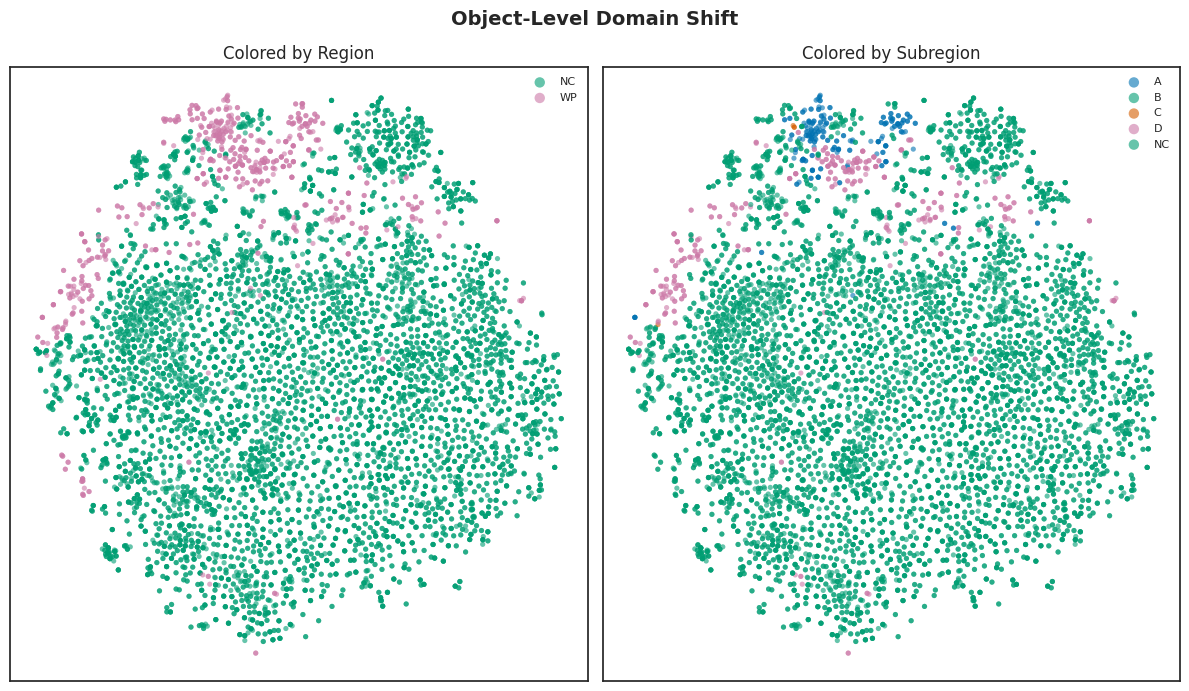

In [17]:
# Plot -- same code as the full-image version, just swap the arrays
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes,
        [obj["region"], obj["subregion"]],
        ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_tsne_obj[mask, 0], coords_2d_tsne_obj[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)

    fig.suptitle("Object-Level Domain Shift",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [5]:
dataset = fo.load_dataset("nc765")
dataset

Name:        nc765
Media type:  image
Num samples: 716
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    ground_truthv2:   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roi_grid:         fiftyone.core.fields.EmbeddedDocumentField

In [30]:
dataset = fo.load_dataset("FLPLAN")

In [ ]:
import numpy as np 
import pandas as pd
print(pd.Series(dataset.values('metadata.width')).unique())
print(pd.Series(dataset.values('metadata.height')).unique())
#np.count_values(dataset.values('metadata.width'))

height = dataset.values("metadata.height")
width = dataset.values("metadata.width")
jj  = zip(width,height)
pd.Series(jj).unique()

[5472 4096 3840 4000]
[3648 2160 3000]


# 5. Tiling grid and positive negative dugong presence

check the file 
```
tiling_export.py
```

6. Tiles Subdataset

Here we create and launch the tiling dataset in a fiftyone instance to see the quality of our dataset and compute the feature extraction with dinov3

In [33]:
from src.create_tile_dataset import create_tile_dataset

dataset = create_tile_dataset(
    path_root="/share/home/e2406743/dataset/tiles_all/umflplan_2048",
    name_dataset="umflplan_T2048ov224",
)


  Found 131 images in positive/images/


  Found 505 images in negative/images/

Adding 636 tile samples to 'umflplan_T2048ov224' ...
 100% |█████████████████| 636/636 [384.9ms elapsed, 0s remaining, 1.7K samples/s]       
Computing metadata...
 100% |█████████████████| 636/636 [948.5ms elapsed, 0s remaining, 670.5 samples/s]      
Done. Dataset 'umflplan_T2048ov224' created with 636 samples.
  type_label counts: {'negative': 505, 'positive': 131}


In [13]:
dataset.count_values("ground_truth.detections.label")

{'0': 1367, '1': 7205}

In [ ]:

dataset = create_tile_dataset(
    path_root="/share/home/e2406743/dataset/tiles_all/wp125_2048",
    name_dataset="wp125_T2048ov224",
)


In [4]:
from src.create_tile_dataset import create_tile_dataset

dataset = create_tile_dataset(
    path_root="/share/home/e2406743/dataset/tiles_all/umflplan",
    name_dataset="umflplan_T1024ov224",
)


  Found 141 images in positive/images/
  Found 2614 images in negative/images/

Adding 2755 tile samples to 'umflplan_T1024ov224' ...
 100% |███████████████| 2755/2755 [1.0s elapsed, 0s remaining, 2.6K samples/s]         
Computing metadata...
 100% |███████████████| 2755/2755 [3.9s elapsed, 0s remaining, 708.3 samples/s]      
Done. Dataset 'umflplan_T1024ov224' created with 2755 samples.
  type_label counts: {'negative': 2614, 'positive': 141}


In [21]:
session = fo.launch_app(dataset, auto=False, port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [22]:
session.refresh()

# Merge, Concat, Add new dataset 

In [34]:
fo.list_datasets()

['FLPLAN',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles_merged',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224']

In [8]:
um_tiles = fo.load_dataset("umflplan_T1024ov224")
um_tiles.get_field_schema().keys()

odict_keys(['id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modified_at', 'type_label', 'ground_truth', 'region', 'mission_name', 'parent_name', 'gt_field', 'min_area_ratio', 'n_boxes_in_tile', 'n_boxes_written', 'source_image', 'tile_name', 'x_start', 'y_start', 'dataset_sr'])

In [ ]:
wp125_tiles = fo.load_dataset("wp125_T1024ov224")
wp125_tiles.get_field_schema().keys()

In [4]:
wp125_tiles.count_values("mission_name")

{'FRIWEN': 945, 'GAM': 405, 'UM': 1185, 'MANTASANDY': 105}

In [9]:
from fiftyone import ViewField
wp_only = wp125_tiles.match(
    ViewField("mission_name").contains_str(["FRIWEN","GAM","MANTASANDY"])
)
UM_WP = wp125_tiles.match(
    ViewField("mission_name").contains_str(["UM"])
)
UM_WP

Dataset:     wp125_T1024ov224
Media type:  image
Num samples: 1185
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.IntField
    n_boxes_written:  f

In [35]:
list_dataset = ['umflplan_T2048ov224','wp125_T2048ov224']
sources = ['UM_flplan','WPmix']
for i,dat in enumerate(list_dataset):
    dataset = fo.load_dataset(dat)
    dataset_source = sources[i]
    for sample in dataset.iter_samples(progress=True):
        sample['dataset_sr'] = dataset_source
        sample.save()


 100% |█████████████████| 636/636 [1.0s elapsed, 0s remaining, 666.5 samples/s]         
 100% |█████████████████| 904/904 [773.8ms elapsed, 0s remaining, 1.2K samples/s]       


In [37]:
#ds1 = fo.load_dataset("nc765_T1024ov224")
ds2 = fo.load_dataset("umflplan_T2048ov224")
ds3 = fo.load_dataset("wp125_T2048ov224")

In [ ]:
new_dataset = fo.Dataset("WPonly_1024ov224", persistent=True)
new_dataset.add_collection(
    wp_only
)

In [11]:
train_nc = fo.load_dataset("nc765_T1024ov224")
new_dataset = fo.Dataset("train_nc_wp_T1024ov224", persistent=True)
new_dataset.add_collection(
    train_nc
)
new_dataset.add_collection(
    wp_only
)
new_dataset

Name:        train_nc_wp_T1024ov224
Media type:  image
Num samples: 7183
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core

In [10]:
um_flplan = fo.load_dataset("umflplan_T1024ov224")
new_dataset = fo.Dataset("UM_teste", persistent=True)
new_dataset.add_collection(
    um_flplan
)
new_dataset.add_collection(
    UM_WP
)
new_dataset

Name:        UM_teste
Media type:  image
Num samples: 3940
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.IntFie

In [39]:
dataset = fo.Dataset("tiles2048_merged", persistent=True)

# dataset.add_collection(
#     ds1
# )

dataset.add_collection(
    ds2
)

dataset.add_collection(
    ds3
)

['6a44dfacac26e9d0f92e8ae8',
 '6a44dfacac26e9d0f92e8ae9',
 '6a44dfacac26e9d0f92e8aea',
 '6a44dfacac26e9d0f92e8aeb',
 '6a44dfacac26e9d0f92e8aec',
 '6a44dfacac26e9d0f92e8aed',
 '6a44dfacac26e9d0f92e8aee',
 '6a44dfacac26e9d0f92e8aef',
 '6a44dfacac26e9d0f92e8af0',
 '6a44dfacac26e9d0f92e8af1',
 '6a44dfacac26e9d0f92e8af2',
 '6a44dfacac26e9d0f92e8af3',
 '6a44dfacac26e9d0f92e8af4',
 '6a44dfacac26e9d0f92e8af5',
 '6a44dfacac26e9d0f92e8af6',
 '6a44dfacac26e9d0f92e8af7',
 '6a44dfacac26e9d0f92e8af8',
 '6a44dfacac26e9d0f92e8af9',
 '6a44dfacac26e9d0f92e8afa',
 '6a44dfacac26e9d0f92e8afb',
 '6a44dfacac26e9d0f92e8afc',
 '6a44dfacac26e9d0f92e8afd',
 '6a44dfacac26e9d0f92e8afe',
 '6a44dfacac26e9d0f92e8aff',
 '6a44dfacac26e9d0f92e8b00',
 '6a44dfacac26e9d0f92e8b01',
 '6a44dfacac26e9d0f92e8b02',
 '6a44dfacac26e9d0f92e8b03',
 '6a44dfacac26e9d0f92e8b04',
 '6a44dfacac26e9d0f92e8b05',
 '6a44dfacac26e9d0f92e8b06',
 '6a44dfacac26e9d0f92e8b07',
 '6a44dfacac26e9d0f92e8b08',
 '6a44dfacac26e9d0f92e8b09',
 '6a44dfacac26

In [40]:
fo.list_datasets()

['FLPLAN',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224']

# Cosine similarity with other images

### functions

In [7]:
# ── New function: cross-image cosine similarity ─────────────────────────────

def compute_cross_image_similarity_map(
    anchor_tokens  : torch.Tensor,
    anchor_row     : int,
    anchor_col     : int,
    anchor_grid_w  : int,
    target_tokens  : torch.Tensor,
    target_grid_h  : int,
    target_grid_w  : int,
) -> tuple:
    """
    Computes cosine similarity between ONE anchor token (from image A) and
    EVERY token in a different image's token tensor (image B).

    Parameters
    ----------
    anchor_tokens  : torch.Tensor (n_patches_A, dim) -- image A's patch tokens
    anchor_row     : int -- row of the anchor token in A's grid
    anchor_col     : int -- col of the anchor token in A's grid
    anchor_grid_w  : int -- A's grid width (needed to flatten row/col -> index)
    target_tokens  : torch.Tensor (n_patches_B, dim) -- image B's patch tokens
    target_grid_h  : int -- B's grid height
    target_grid_w  : int -- B's grid width

    Returns
    -------
    raw_map  : np.ndarray (target_grid_h, target_grid_w)  values in [-1, 1]
    norm_map : np.ndarray (target_grid_h, target_grid_w)  values in [0, 1]
    """
    anchor_idx = anchor_row * anchor_grid_w + anchor_col

    anchor_normed = F.normalize(anchor_tokens.float(), dim=-1)
    anchor_vec    = anchor_normed[anchor_idx]                     # (dim,)

    target_normed = F.normalize(target_tokens.float(), dim=-1)    # (n_patches_B, dim)
    sim_scores     = (target_normed @ anchor_vec).numpy()          # (n_patches_B,)

    raw_map = sim_scores.reshape(target_grid_h, target_grid_w)

    vmin, vmax = raw_map.min(), raw_map.max()
    norm_map   = (raw_map - vmin) / (vmax - vmin + 1e-8)

    return raw_map, norm_map


# ── New orchestrator: 2x2 cross-image comparison plot ────────────────────────

def plot_cross_image_similarity(
    dataset,
    anchor_id    : str,
    target_id    : str,
    processor,
    model        : torch.nn.Module,
    tile_size    : int   = 1024,
    stride       : int   = 16,
    n_registers  : int   = 4,
    device       : str   = DEVICE,
    use_norm     : bool  = True,
    save_path    : str   = None,
    dpi          : int   = 150,
):
    """
    2x2 figure comparing one image's dugong-anchor token against itself
    (self-similarity) and against a different image's tokens entirely
    (cross-similarity).

        Row 1, Col 1: image A raw tile + bbox + anchor cross
        Row 1, Col 2: image B raw tile (no bbox -- B is treated as a flat
                      grid of tokens, per design)
        Row 2, Col 1: A's anchor vs A's own tokens (self-similarity)
        Row 2, Col 2: A's anchor vs B's tokens (cross-similarity)

    Both tiles are assumed to already be fixed-size (tile_size x tile_size)
    standalone images -- no crop-window/edge-sliding needed, since they
    were produced by the tiling pipeline at native resolution already.
    """
    # ── Load both samples ────────────────────────────────────────────────────
    sample_a = load_sample(dataset, anchor_id)
    sample_b = load_sample(dataset, target_id)

    # Only A needs its ground-truth centroid -- B is purely a token grid
    cx_a, cy_a, detection_a, img_w_a, img_h_a = get_centroid_pixels(sample_a)

    grid_h = grid_w = tile_size // stride
    anchor_row, anchor_col = pixels_to_token(cx_a, cy_a, stride, grid_h, grid_w)

    print(f"Image A anchor: row={anchor_row}, col={anchor_col} "
          f"(grid {grid_h}x{grid_w})")

    # ── Load raw tiles (already native tile_size x tile_size, no cropping) ───
    pil_a = Image.open(sample_a.filepath).convert("RGB")
    pil_b = Image.open(sample_b.filepath).convert("RGB")

    # ── Inference, once per image ────────────────────────────────────────────
    tokens_a, grid_h_a, grid_w_a = extract_patch_tokens(
        pil_a, processor, model, stride, n_registers, device,
    )
    tokens_b, grid_h_b, grid_w_b = extract_patch_tokens(
        pil_b, processor, model, stride, n_registers, device,
    )

    # ── Self-similarity (A vs A, reusing the original function) ─────────────
    raw_self, norm_self = compute_cosine_similarity_map(
        tokens_a, anchor_row, anchor_col, grid_h_a, grid_w_a,
    )

    # ── Cross-similarity (A's anchor vs B's tokens, the new function) ───────
    raw_cross, norm_cross = compute_cross_image_similarity_map(
        tokens_a, anchor_row, anchor_col, grid_w_a,
        tokens_b, grid_h_b, grid_w_b,
    )

    self_map  = norm_self  if use_norm else raw_self
    cross_map = norm_cross if use_norm else raw_cross
    vmin, vmax = (0, 1) if use_norm else (-1, 1)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(11, 11), facecolor=BG)
    fig.suptitle(
        f"Self vs Cross-Image Patch Similarity\n"
        f"A: {sample_a.id}   B: {sample_b.id}",
        color=WHITE, fontsize=12, fontweight="bold", y=1.01,
    )

    # Row 1, Col 1 -- image A + bbox + anchor cross
    ax = axes[0, 0]
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_a))
    bx, by, bw, bh = detection_a.bounding_box
    rect = mpatches.Rectangle(
        (bx * tile_size, by * tile_size), bw * tile_size, bh * tile_size,
        linewidth=1.5, edgecolor=BBOX_CLR, facecolor="none", zorder=3,
    )
    ax.add_patch(rect)
    cross_x = (anchor_col + 0.5) * stride
    cross_y = (anchor_row + 0.5) * stride
    ax.plot(cross_x, cross_y, "+", color=ANCHOR_C, markersize=16, markeredgewidth=2.5, zorder=4)
    ax.set_title("Image A (anchor source)", color=WHITE, fontsize=10)
    ax.axis("off")

    # Row 1, Col 2 -- image B, no bbox
    ax = axes[0, 1]
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_b))
    ax.set_title("Image B (comparison target)", color=WHITE, fontsize=10)
    ax.axis("off")

    # Row 2, Col 1 -- self-similarity map
    ax = axes[1, 0]
    ax.set_facecolor(BG)
    im1 = ax.imshow(self_map, cmap=CMAP, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.plot(anchor_col, anchor_row, "+", color=ANCHOR_C, markersize=12, markeredgewidth=2.0)
    ax.set_title("A's anchor vs A's own tokens", color=WHITE, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    # Row 2, Col 2 -- cross-similarity map
    ax = axes[1, 1]
    ax.set_facecolor(BG)
    im2 = ax.imshow(cross_map, cmap=CMAP, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title("A's anchor vs B's tokens", color=WHITE, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved -> {save_path}")

    plt.show()
    return fig, (raw_self, raw_cross)

### pipeline

In [13]:
dataset.values('id')[7600]

'6a33d1a719d8f6f6ef569a3a'

In [23]:
dataset

Name:        tiles_merged
Media type:  image
Num samples: 11123
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.I

In [32]:
from fiftyone import ViewField

dataset.match(
    ViewField('type_label').contains_str('positive')
).values('id')[1500]

'6a33c2d28be790ca1e89a888'

In [ ]:
fig, (raw_self, raw_cross) = plot_cross_image_similarity(
    dataset=dataset,
    anchor_id='6a33c2d08be790ca1e89a2ac',
    target_id='6a33d1a719d8f6f6ef569a3a',
    processor=processor,
    model=base_model,
    tile_size=1024,
    stride=STRIDE,
    n_registers=N_REGISTERS,
    device=DEVICE,
    use_norm=True,
    save_path="cross_image_similarity.png",
)

In [ ]:
fig, (raw_self, raw_cross) = plot_cross_image_similarity(
    dataset=dataset,
    anchor_id='6a33c2d08be790ca1e89a310',
    target_id='6a33c2d28be790ca1e89a694',
    processor=processor,
    model=base_model,
    tile_size=1024,
    stride=STRIDE,
    n_registers=N_REGISTERS,
    device=DEVICE,
    use_norm=True,
    save_path="cros2s_image_similarity.png",
)

In [ ]:
fig, (raw_self, raw_cross) = plot_cross_image_similarity(
    dataset=dataset,
    anchor_id='6a33c2d08be790ca1e89a372',
    target_id='6a33c2d28be790ca1e89a888',
    processor=processor,
    model=base_model,
    tile_size=1024,
    stride=STRIDE,
    n_registers=N_REGISTERS,
    device=DEVICE,
    use_norm=True,
    save_path="cros3s_image_similarity.png",
)

# Plot the PCA of the embeddings for the image. 

In [ ]:
import numpy as np
from sklearn.preprocessing import normalize

data_embedding_tile        = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz")

sample_ids = data_embedding_tile['sample_ids']

embedding_retrieved = data_embedding_tile['embeddings']

In [26]:
norm_embding[num_random].reshape(1,-1).shape

(1, 1024)

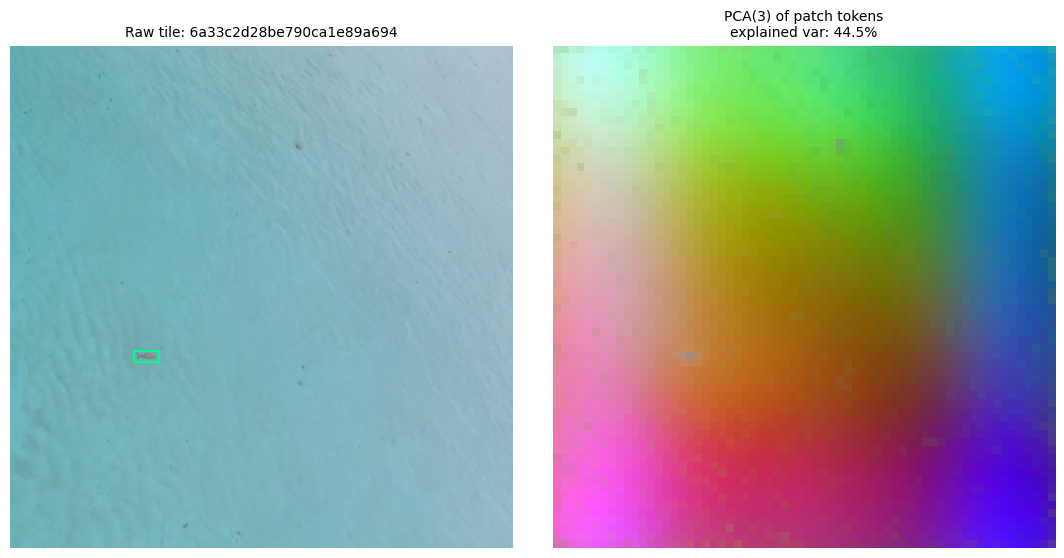

In [39]:
# ── PCA of patch tokens within ONE tile -> spatial RGB feature map ──────────
from sklearn.decomposition import PCA
import numpy as np

def pca_patch_tokens_to_rgb(patch_tokens: torch.Tensor, grid_h: int, grid_w: int):
    """
    Fits PCA across the patch tokens of a SINGLE image (one row per patch),
    projects onto the first 3 components, and reshapes into a spatial RGB
    feature map of shape (grid_h, grid_w, 3), each channel normalised to [0,1].
    """
    tokens_np = patch_tokens.float().numpy()   # (n_patches, dim)

    pca = PCA(n_components=3)
    coords_3d = pca.fit_transform(tokens_np)    # (n_patches, 3)

    # Normalise each component independently to [0, 1]
    coords_norm = np.zeros_like(coords_3d)
    for i in range(3):
        c = coords_3d[:, i]
        coords_norm[:, i] = (c - c.min()) / (c.max() - c.min() + 1e-8)

    rgb_map = coords_norm.reshape(grid_h, grid_w, 3)
    return rgb_map, pca.explained_variance_ratio_


# ── Run on one tile, plot side by side with the raw image ───────────────────
tile_id = "6a33c2d28be790ca1e89a694"
sample  = dataset[tile_id]
pil_img = Image.open(sample.filepath).convert("RGB")

patch_tokens, grid_h, grid_w = extract_patch_tokens(
    pil_img, processor, base_model, STRIDE, N_REGISTERS, DEVICE,
)

rgb_map, explained_var = pca_patch_tokens_to_rgb(patch_tokens, grid_h, grid_w)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

axes[0].imshow(np.array(pil_img))
if sample.ground_truth and sample.ground_truth.detections:
    img_w, img_h = pil_img.size
    for det in sample.ground_truth.detections:
        bx, by, bw, bh = det.bounding_box
        rect = mpatches.Rectangle(
            (bx * img_w, by * img_h), bw * img_w, bh * img_h,
            linewidth=1.5, edgecolor="#00ff88", facecolor="none",
        )
        axes[0].add_patch(rect)
axes[0].set_title(f"Raw tile: {tile_id}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(rgb_map)
axes[1].set_title(
    f"PCA(3) of patch tokens\nexplained var: {explained_var.sum():.1%}",
    fontsize=10,
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Clustering and Uniqueness

In [38]:
from fiftyone import ViewField
dataset.match(
    ViewField("type_label").contains_str("positive")
).values('id')[1000]

'6a33c2d28be790ca1e89a694'

In [6]:
import numpy as np
from sklearn.preprocessing import normalize

data_embedding_tile        = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz")

sample_ids = data_embedding_tile['sample_ids']

In [12]:
# load the functions
from src.active_learning import compute_clustering, compute_uniqueness_field_v2

In [ ]:
cluster_labels, emb_norm, sample_ids = compute_clustering(
    dataset=dataset,
    embeddings=data_embedding_tile["embeddings"],
    sample_ids=data_embedding_tile["sample_ids"],
    cluster_field="cluster_label",
    n_clusters=15,
)

In [13]:
uniqueness_score, _ = compute_uniqueness_field_v2(
    dataset,
    embeddings = data_embedding_tile["embeddings"],
    sample_ids = data_embedding_tile["sample_ids"],
    uniqueness_field   = "uniqueness_score",
    cluster_field = "cluster_label",   # if given, compute uniqueness per cluster
    k = 10,
    decay= "exponential",
    decay_param = 0.5,
    save  = True,
    verbose = True,
)

  Using pre-loaded embeddings array: (11123, 1024) (11123 sample_ids).
  Resolved 11123 embeddings, dim=1024
  Decay: exponential  param=0.5  k=10  weights=[0.607, 0.368, 0.223, 0.135, 0.082, 0.050, 0.030, 0.018, 0.011, 0.007]
  Loading cluster labels from 'cluster_label' ...
 100% |█████████████| 11123/11123 [3.3s elapsed, 0s remaining, 6.4K samples/s]        
  Found 15 clusters.
    cluster   0: n=1037  k_eff=10  mean=0.2302  max=1.0000
    cluster   1: n= 331  k_eff=10  mean=0.2097  max=1.0000
    cluster   2: n=1210  k_eff=10  mean=0.3070  max=1.0000
    cluster   3: n= 509  k_eff=10  mean=0.0920  max=1.0000
    cluster   4: n= 632  k_eff=10  mean=0.2535  max=1.0000
    cluster   5: n= 838  k_eff=10  mean=0.2026  max=1.0000
    cluster   6: n= 673  k_eff=10  mean=0.2693  max=1.0000
    cluster   7: n= 365  k_eff=10  mean=0.4267  max=1.0000
    cluster   8: n=1142  k_eff=10  mean=0.1338  max=1.0000
    cluster   9: n= 887  k_eff=10  mean=0.1381  max=1.0000
    cluster  10: n=1205  

In [14]:
session = fo.launch_app(dataset, auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


## Clustering Patches

In [7]:
dataset.to_patches("ground_truth")

Dataset:     tiles_merged
Media type:  image
Num patches: 9265
Patch fields:
    id:               fiftyone.core.fields.ObjectIdField
    sample_id:        fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detection)
View stages:
    1. ToPatches(field='ground_truth', config=None)

In [12]:
import numpy as np

In [13]:
data = np.load("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/objects_emb/all_objects_embeddings.npz")

In [10]:
data

NpzFile '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/objects_emb/all_objects_embeddings.npz' with keys: object_embeddings, detection_ids, sample_ids

In [6]:
dataset.first()

<Sample: {
    'id': '6a33c2d08be790ca1e89a2ac',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH014205-611f8c7997ea4_1808__tile_0_800_t1024_o224.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 90472,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 18, 11, 29, 1, 457000),
    'last_modified_at': datetime.datetime(2026, 6, 30, 11, 16, 1, 969000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33c2c48be790ca1e898130',
                'attributes': {},
                'tags': [],
                'label': '1',
                'bounding_box': [0.4365234375, 0.0556640625, 0.04296875, 0.046875],
                'mask': None,
                'mask_path': None,
                'confidence': None,
       

In [16]:
data

NpzFile '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/objects_emb/all_objects_embeddings.npz' with keys: object_embeddings, detection_ids, sample_ids

In [13]:
from src.active_learning_patches import compute_clustering_patches, compute_uniqueness_patches


cluster_labels, emb_norm, sample_ids, detection_ids = compute_clustering_patches(
    dataset=dataset,
    embeddings=data["object_embeddings"],
    sample_ids=data["sample_ids"],
    detection_ids=data["detection_ids"],
    patches_field="ground_truth",
    cluster_field="objects_cluster_label",
    n_clusters=20,
)

# uniqueness_score, _ = compute_uniqueness_patches(
#     dataset=dataset,
#     embeddings=data["object_embeddings"],
#     sample_ids=data["sample_ids"],
#     detection_ids=data["detection_ids"],
#     patches_field="ground_truth",
#     uniqueness_field="uniqueness_score",
#     cluster_field="cluster_label",
#     k=10,
#     decay="exponential",
#     decay_param=0.5,
#     save=True,
#     verbose=True,
# )

  Clustering 9265 object/patch embeddings via 'kmeans' ...



Could not connect session, trying again in 10 seconds

    Cluster sizes: {0: 427, 1: 631, 2: 534, 3: 517, 4: 402, 5: 365, 6: 488, 7: 527, 8: 338, 9: 270, 10: 510, 11: 407, 12: 552, 13: 384, 14: 413, 15: 671, 16: 606, 17: 313, 18: 407, 19: 503}
  Writing 'objects_cluster_label' onto 9265 detections across 2546 samples ...

Could not connect session, trying again in 10 seconds

    Done: 9265 detections updated.


In [26]:
dataset.delete_brain_run('tsne_dug_obj')

In [22]:
session.refresh()

In [13]:
from fiftyone import ViewField

PATCHES_FIELD = "ground_truth"

# ── Restrict to positive tiles only, before computing anything ──────────────
positive_view = dataset.match(ViewField("type_label") == "positive")
print(f"Positive tiles: {len(positive_view)} / {len(dataset)} total")

# Sanity check: every sample in this view should actually have detections
n_empty = positive_view.match(ViewField(f"{PATCHES_FIELD}.detections").length() == 0).count()
if n_empty > 0:
    print(f"  WARNING: {n_empty} 'positive' tiles have an EMPTY '{PATCHES_FIELD}' "
          f"field -- type_label and ground_truth appear inconsistent for these "
          f"samples. Check the tiling pipeline output for this dataset.")


Positive tiles: 2546 / 11123 total


In [14]:
# ── Check the actual shapes before doing anything else ──────────────────────
print(f"object_embeddings shape: {data['object_embeddings'].shape}")
print(f"detection_ids shape:     {data['detection_ids'].shape}")
print(f"sample_ids shape:        {data['sample_ids'].shape}")

print(f"\npositive_view detection count: "
      f"{positive_view.count(f'{PATCHES_FIELD}.detections')}")

object_embeddings shape: (9265, 1024)
detection_ids shape:     (9265,)
sample_ids shape:        (9265,)

positive_view detection count: 9265


In [16]:
# ── Fast, single-pass dict reconstruction (Option A: simple, O(N)) ──────────
from collections import defaultdict
import numpy as np

groups = defaultdict(list)
for sid, emb in zip(data["sample_ids"], data["object_embeddings"]):
    groups[sid].append(emb)

object_embeddings_dict = {sid: np.stack(embs) for sid, embs in groups.items()}

print(f"Reconstructed dict for {len(object_embeddings_dict)} samples.")

Reconstructed dict for 2546 samples.



Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



In [17]:
session

Dataset:          tiles_merged
Media type:       image
Num samples:      11123
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



In [ ]:
fob.compute_visualization(
    positive_view,
    patches_field=PATCHES_FIELD,
    embeddings=object_embeddings_dict,
    method="tsne",
    brain_key="obj_emb_tiles",
    create_index=True,
    seed=42,
    max_iter=1000,
    progress=True,
)

Generating visualization...


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 9265 samples in 0.001s...
[t-SNE] Computed neighbors for 9265 samples in 2.737s...
[t-SNE] Computed conditional probabilities for sample 1000 / 9265
[t-SNE] Computed conditional probabilities for sample 2000 / 9265
[t-SNE] Computed conditional probabilities for sample 3000 / 9265
[t-SNE] Computed conditional probabilities for sample 4000 / 9265
[t-SNE] Computed conditional probabilities for sample 5000 / 9265
[t-SNE] Computed conditional probabilities for sample 6000 / 9265
[t-SNE] Computed conditional probabilities for sample 7000 / 9265
[t-SNE] Computed conditional probabilities for sample 8000 / 9265
[t-SNE] Computed conditional probabilities for sample 9000 / 9265
[t-SNE] Computed conditional probabilities for sample 9265 / 9265
[t-SNE] Mean sigma: 3.191675
[t-SNE] Computed conditional probabilities in 0.248s
[t-SNE] Iteration 50: error = 91.7309341, gradient norm = 0.0053078 (50 iterations in 4.863s)
[t-SNE] Iteration 100: 


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



In [ ]:
session = fo.launch_app(dataset,auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.



Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



# Cosine SImilarity at full pooled embedding 

In [9]:
import numpy as np

In [10]:
data_tile = np.load('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/merged_1024o224_fullimage_embeddings.npz')

In [14]:
dataset.save_view("positive", positive_view)

In [15]:
session.refresh()

In [16]:
session.freeze

<bound method Session.freeze of Dataset:          tiles_merged
Media type:       image
Num samples:      2546
Selected samples: 5
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. Match(filter={'$expr': {'$eq': [...]}})>

In [22]:
from src.similarity_utils import build_embedding_lookup, calculate_cosine_similarity

# Full-tile embeddings (keyed by sample_id)
tile_lookup = build_embedding_lookup(data_tile["sample_ids"], data_tile["embeddings"])
sim = calculate_cosine_similarity('6a33c2d28be790ca1e89a674',
                                   [
                                    '6a33c2d28be790ca1e89a682',
                                    '6a33c2d28be790ca1e89a67f',
                                    '6a33c2d28be790ca1e89a673',
                                    '6a33c2d28be790ca1e89a679',
                                    '6a33c2d28be790ca1e89a67a'], 
                                  tile_lookup
                                  )

# # Object embeddings (keyed by detection_id)
# object_lookup = build_embedding_lookup(data["detection_ids"], data["object_embeddings"])
# sims = calculate_cosine_similarity(anchor_detection_id, [det_id_1, det_id_2, det_id_3], object_lookup)
# print(sims)   # {'det_id_1': 0.83, 'det_id_2': 0.41, 'det_id_3': 0.77}

In [20]:
session.freeze

<bound method Session.freeze of Dataset:          tiles_merged
Media type:       image
Num samples:      2546
Selected samples: 6
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. Match(filter={'$expr': {'$eq': [...]}})>

In [21]:
session.selected

['6a33c2d28be790ca1e89a674',
 '6a33c2d28be790ca1e89a682',
 '6a33c2d28be790ca1e89a67f',
 '6a33c2d28be790ca1e89a673',
 '6a33c2d28be790ca1e89a679',
 '6a33c2d28be790ca1e89a67a']

In [23]:
sim

{'6a33c2d28be790ca1e89a682': 0.8837021589279175,
 '6a33c2d28be790ca1e89a67f': 0.9063564538955688,
 '6a33c2d28be790ca1e89a673': 0.975446343421936,
 '6a33c2d28be790ca1e89a679': 0.9225451350212097,
 '6a33c2d28be790ca1e89a67a': 0.9481563568115234}

In [24]:
dataset.first()

<Sample: {
    'id': '6a33c2d08be790ca1e89a2ac',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/tiles_all/nc765/positive/images/GH014205-611f8c7997ea4_1808__tile_0_800_t1024_o224.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 90472,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 18, 11, 29, 1, 457000),
    'last_modified_at': datetime.datetime(2026, 6, 30, 11, 52, 21, 103000),
    'type_label': 'positive',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a33c2c48be790ca1e898130',
                'attributes': {},
                'tags': [],
                'label': '1',
                'bounding_box': [0.4365234375, 0.0556640625, 0.04296875, 0.046875],
                'mask': None,
                'mask_path': None,
                'confidence': None,
      

In [26]:
from pathlib import Path
vv = dataset.values("source_image")
vvv = [Path(v).stem for v in vv]

In [27]:
dataset.set_values("source_stem",vvv)

In [30]:
len(positive_view.count_values('source_stem').keys())

951

In [31]:
positive_view

Dataset:     tiles_merged
View name:   positive
Media type:  image
Num samples: 2546
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    type_label:       fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    gt_field:         fiftyone.core.fields.StringField
    min_area_ratio:   fiftyone.core.fields.FloatField
    n_boxes_in_tile:  fiftyone.core.fields.IntField
    n